In [1]:
# Import statements:
import numpy as np
import scipy.linalg
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib import rc
import scipy.constants as cnst
import schemdraw
import schemdraw.elements as elm
from PIL import Image
import h5py
from tqdm import tqdm

In [14]:
t = np.zeros(5)
for i, zero in enumerate(t):
    print(i)
    print(zero)

0
0.0
1
0.0
2
0.0
3
0.0
4
0.0


In [3]:
plt.rcParams.update({'font.size': 8})
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})

# Function bank:

In [4]:
def nHat(nLevels):
    # Returns the n operator in the charge basis.
    # nLevels: Number of levels used to represent the operator. 
    n = np.matrix(np.diag(np.arange(-nLevels, nLevels+1, 1)), dtype=complex)
    return n

def cosPhiHat(nLevels):
    # Returns the Josephson potential in the charge basis.
    # nLevels: Number of levels used to represent the operator. 
    cosPhi = np.matrix(np.diag(np.repeat(0.5, 2*nLevels), -1) + np.diag(np.repeat(0.5, 2*nLevels), -1).T, dtype=complex)
    return cosPhi

def hTransmon(EJ, EC, nG, nLevels):
    # Returns the transmon Hamiltonian in the charge basis.
    # EJ: Josephson energy
    # EC: Charging energy
    # nG: Offset charge
    # nLevels: Number of levels used to represent the Hamiltonian. 
    n = nHat(nLevels)
    cosPhi = cosPhiHat(nLevels)
    eye = np.matrix(np.diag(np.repeat(1, 1 + 2*nLevels)), dtype=complex)
    H = 4*EC*((n-(nG*eye))**2) - EJ*cosPhi
    return H

def sGaussian(t, sigma, center):
    # Gaussian envelope with width "sigma" and offset "center".
    return (1 / (sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*(((t - center)/sigma)**2))

def sGaussianDerivative(t, sigma, center):
    # Gaussian envelope with width "sigma" and offset "center".
    return -((t-center)/(sigma**2))*sGaussian(t, sigma, center)

def pulse(t, iAmp, iEnvelope, qAmp, qEnvelope, omegaD, quadArgs):
    # Time dependent part of the drive for a standard pulse.
    iArgs = quadArgs['iArgs']
    qArgs = quadArgs['qArgs']
    I = iAmp*iEnvelope(t, **iArgs)
    Q = qAmp*qEnvelope(t, **qArgs)
    return I*np.sin(omegaD*t) + Q*np.cos(omegaD*t)

def hDrive(pulse, rabiMatEl):
    # Drive Hamiltonian in the lab frame:
    return pulse*rabiMatEl

def hDriveRF(h0, pulse, rabiMatEl):
    # Drive Hamiltonian in the rotating frame:
    return expm(1j*h0*t) @ hDrive(pulse, rabiMatEl) @ expm(-1j*h0*t)

# Pulse without drag:

## Initialize the Hamiltonian:

In [74]:
# Define the parameters of the simulation:
nLevels = 100 # Number of charge states considered (basis runs from -nLevels to nLevels)
nEnergies = (2*nLevels) + 1
nG = 0 
n = nHat(nLevels)
# EJ = 2*np.pi*10e9 # rad/s
# EC = 2*np.pi*200e6 # rad/s
EJ = 10e9 # Hz
EC = 200e6 # Hz
sigmaGate = 1e-9 # s, variance (sigma) of gaussian pulse (full pulse with is tGate ~ 6*sigmaGate)
theta = np.pi

# Determine the energy eigenvalues and eigenvectors of the bare transmon Hamiltonian:
h = hTransmon(EJ, EC, nG, nLevels)
energyEigVals, energyEigVecs = scipy.linalg.eigh(h)
omegaD = 2*np.pi*(energyEigVals[1] - energyEigVals[0]) # Drive frequency

# Write the bare transmon Hamiltonian in the diagonal basis:
h0 = np.matrix(np.diag(2*np.pi*(energyEigVals - energyEigVals[0]))) # Shift the energies so that omega0 = 0

# Write the drive Hamiltonian (without the time-dependent part of the drive) in terms of the diagonal basis:
rabiMatEl = np.matrix(np.zeros((nEnergies, nEnergies)))
for i in range(nEnergies):
    for j in range(nEnergies):
        matEl = (energyEigVecs[:, i].conj().T @ n @ energyEigVecs[:, j])[0,0] # <i|n|j>
        rabiMatEl[i, j] = theta*matEl

/var/folders/m8/gbh7nps52zzfb187_b37kb540000gn/T/ipykernel_67524/3686146983.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  rabiMatEl[i, j] = theta*matEl


## Define the pulse and plot it:

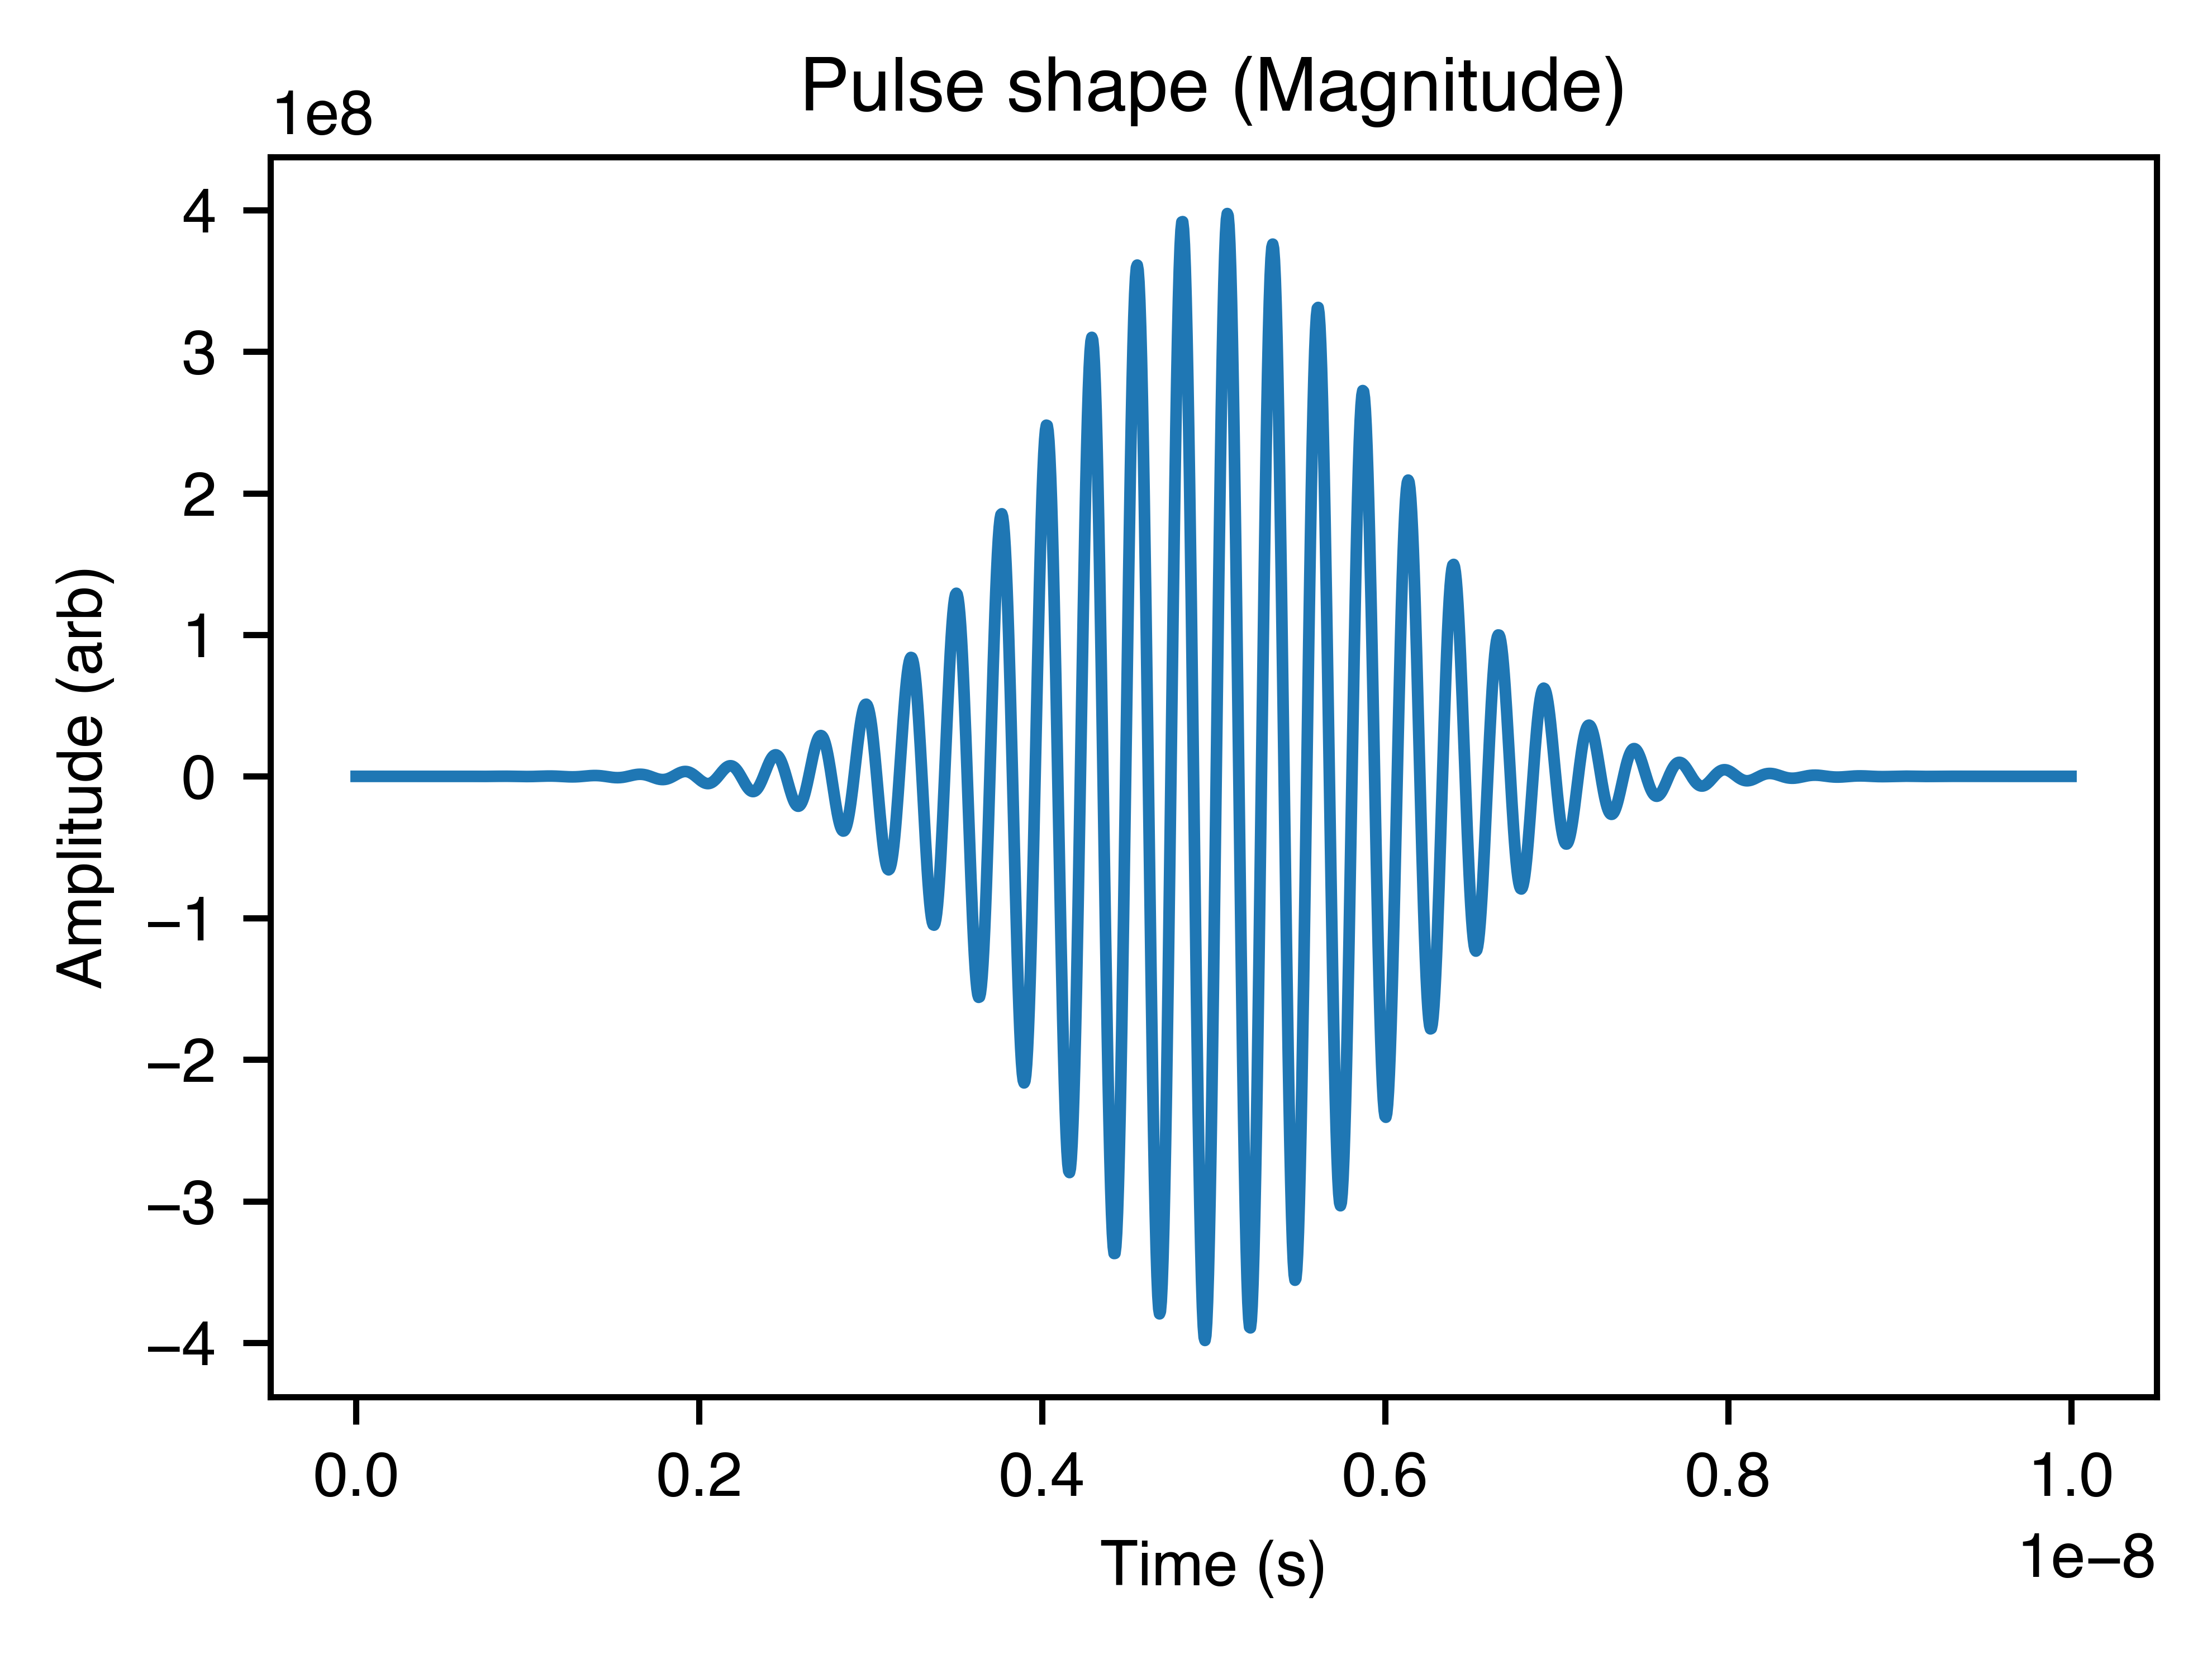

In [75]:
# Pulse parameters:
iAmp = 1
iEnvelope = sGaussian
qAmp = 0
qEnvelope = sGaussian
quadArgs = {
    'iArgs': {'sigma': sigmaGate, 'center': 5*sigmaGate},
    'qArgs': {'sigma': sigmaGate, 'center': 5*sigmaGate}
}

# Define the time discretization:
tFinal = 10*sigmaGate
nTimes = 2000
dt = tFinal/nTimes
times = np.linspace(0, tFinal, num=nTimes+1, endpoint=True)
pulseVals = pulse(times, iAmp, iEnvelope, qAmp, qEnvelope, omegaD, quadArgs)

fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, pulseVals)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (Magnitude)')
plt.tight_layout()

## Evolve the system according to the pulse:

In [58]:
# Define the initial state:
psi = np.zeros(nEnergies, dtype=np.complex128)
psi[0] = 1
psi = np.matrix(psi).T

# Define the matrix to contain the state amplitudes vs time:
populations = np.matrix(np.zeros((nEnergies, nTimes+1), dtype=np.complex128))
populations[:,0] = psi

# Evolve the system:
for i in tqdm(range(nTimes)):
    t = dt*(i+1)
    hTildeRF = hDriveRF(h0, pulseVals[i+1], rabiMatEl)
    psi = expm(-1j*hTildeRF*dt) @ psi
    populations[:,i+1] = psi

  0%|                                                                                                  | 0/2000 [00:00<?, ?it/s]/Users/kevindcrowley/opt/anaconda3/lib/python3.9/site-packages/scipy/sparse/linalg/_onenormest.py:154: RuntimeWarning: overflow encountered in true_divide
  Y /= np.abs(Y)
/Users/kevindcrowley/opt/anaconda3/lib/python3.9/site-packages/scipy/sparse/linalg/_onenormest.py:154: RuntimeWarning: invalid value encountered in true_divide
  Y /= np.abs(Y)
100%|███████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [05:14<00:00,  6.35it/s]


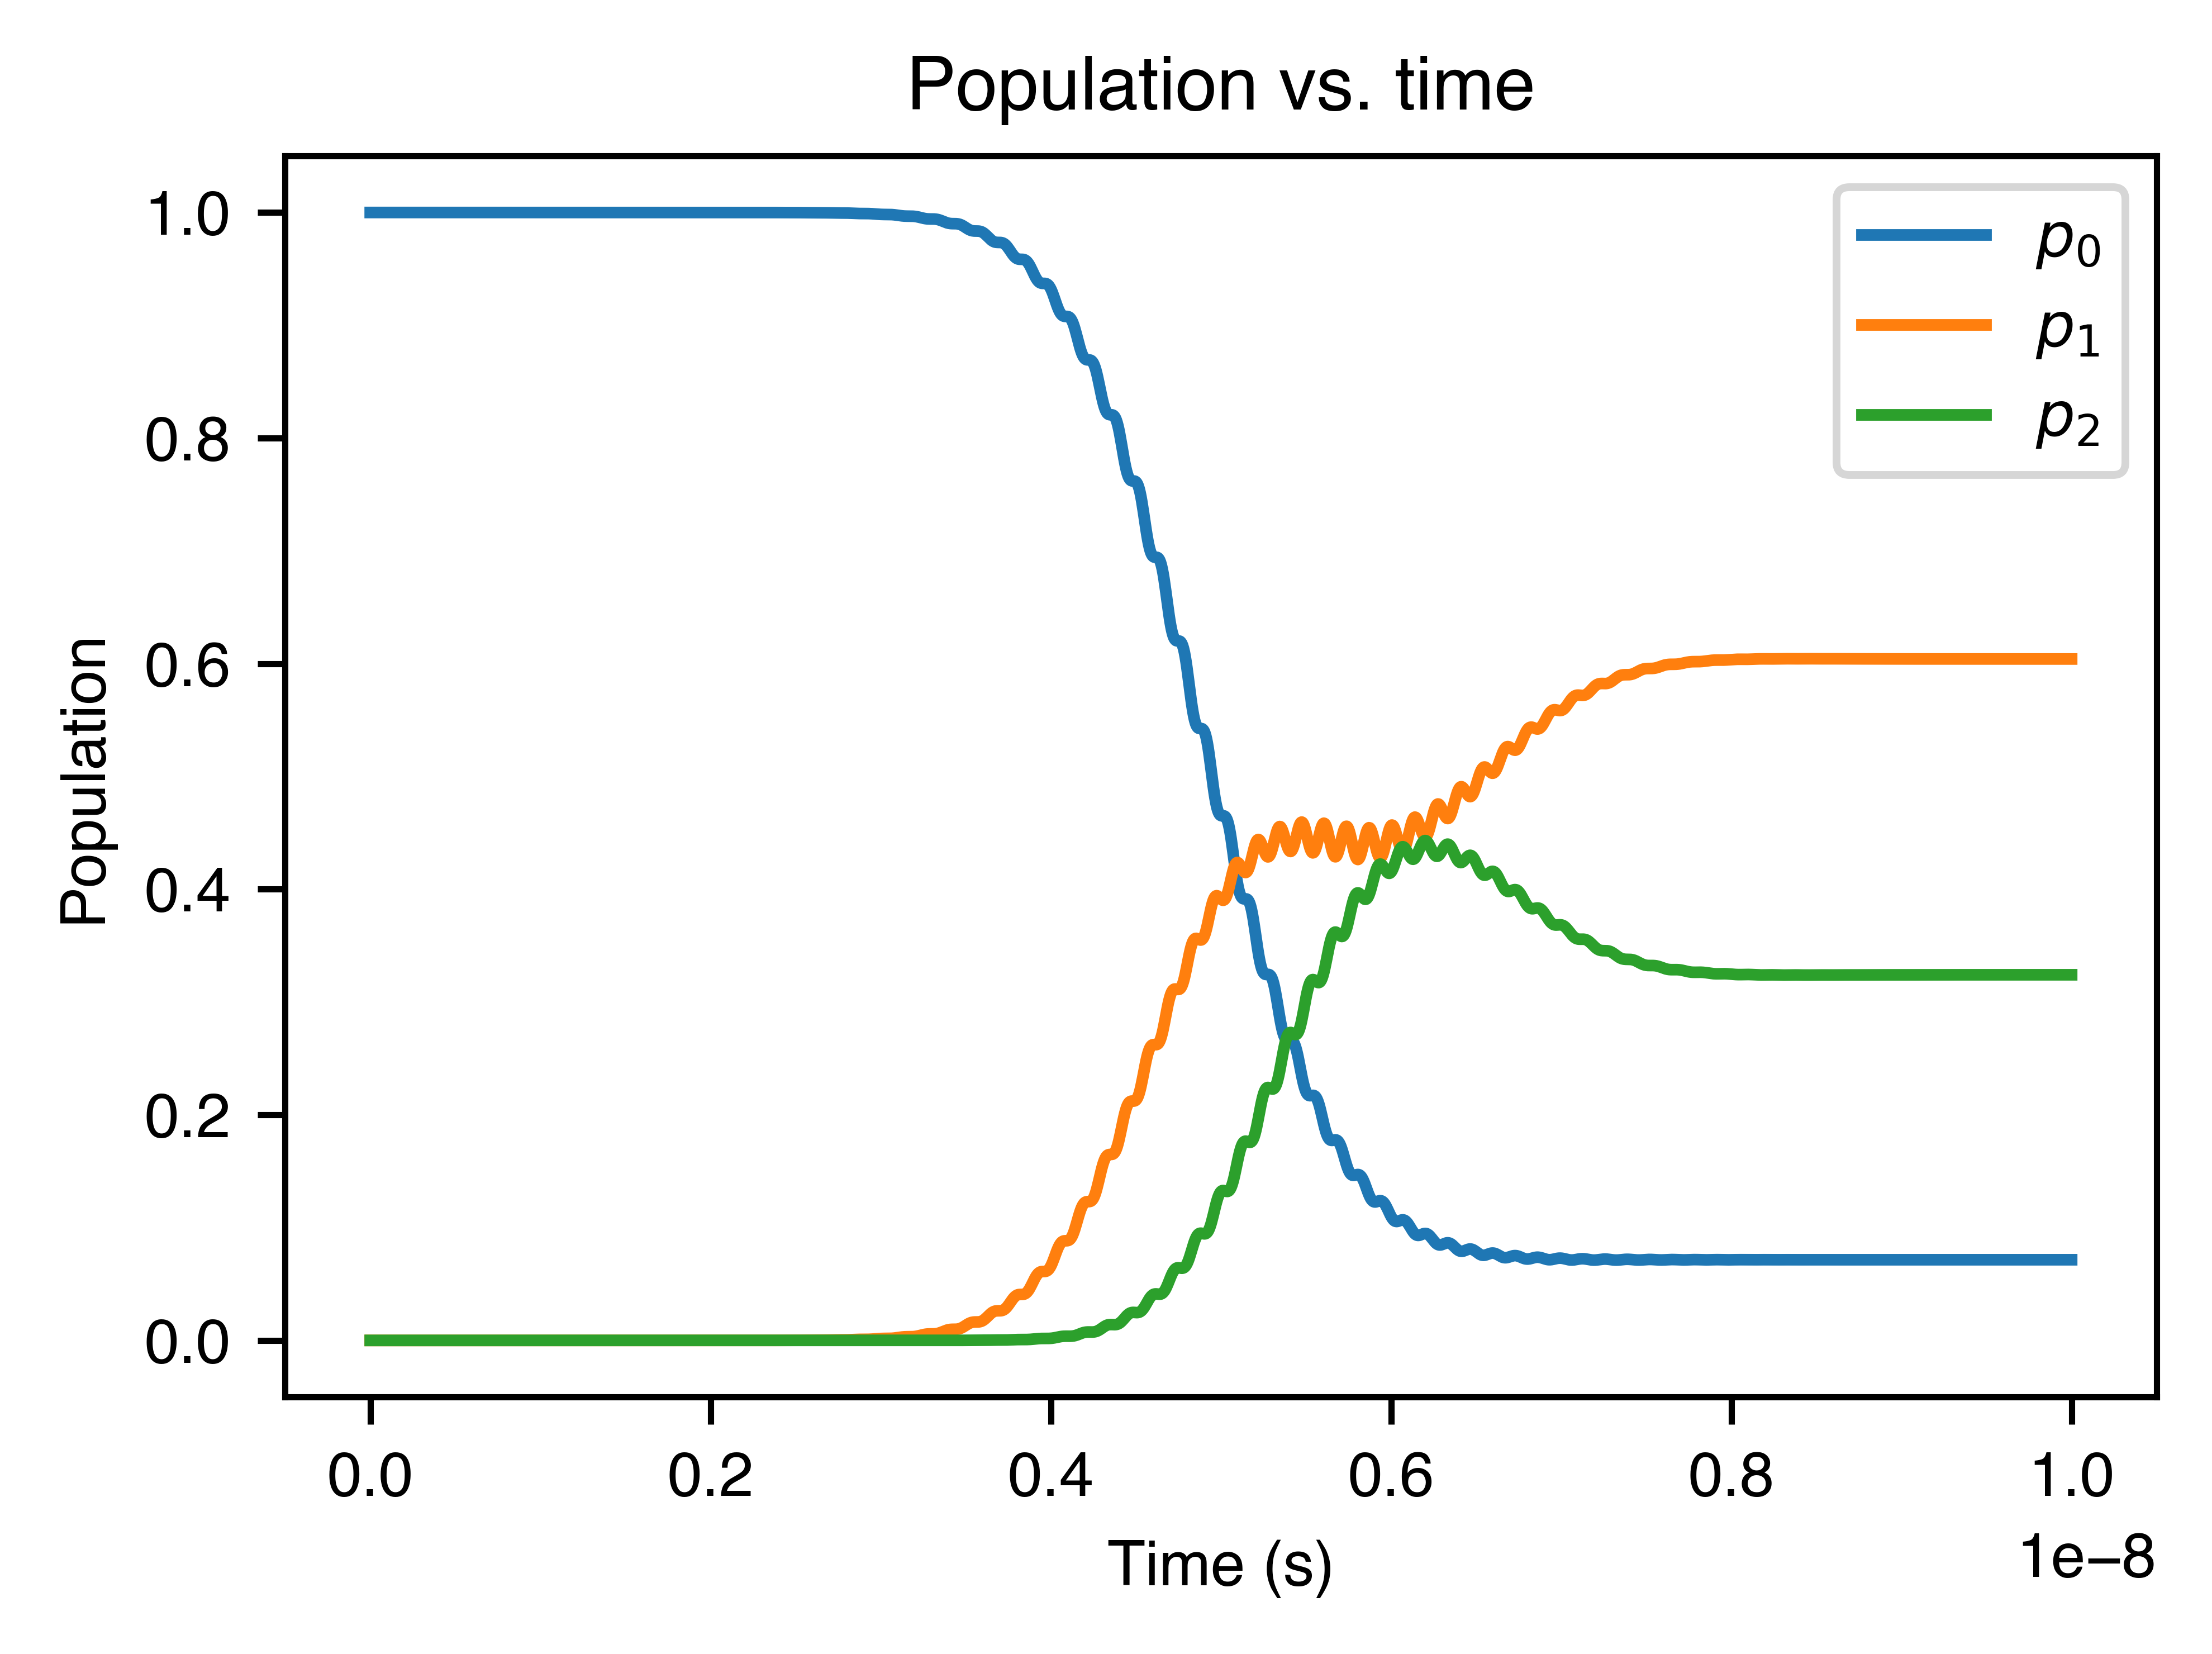

In [59]:
# Plot the results:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
p0 = np.square(np.abs(populations[0, :].A1))
ax.plot(times, p0, label='$p_0$')
p1 = np.square(np.abs(populations[1, :].A1))
ax.plot(times, p1, label='$p_1$')
p2 = np.square(np.abs(populations[2, :].A1))
ax.plot(times, p2, label='$p_2$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Population')
ax.legend()
ax.set_title('Population vs. time')
plt.tight_layout()

100%|█████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [01:58<00:00, 16.84it/s]


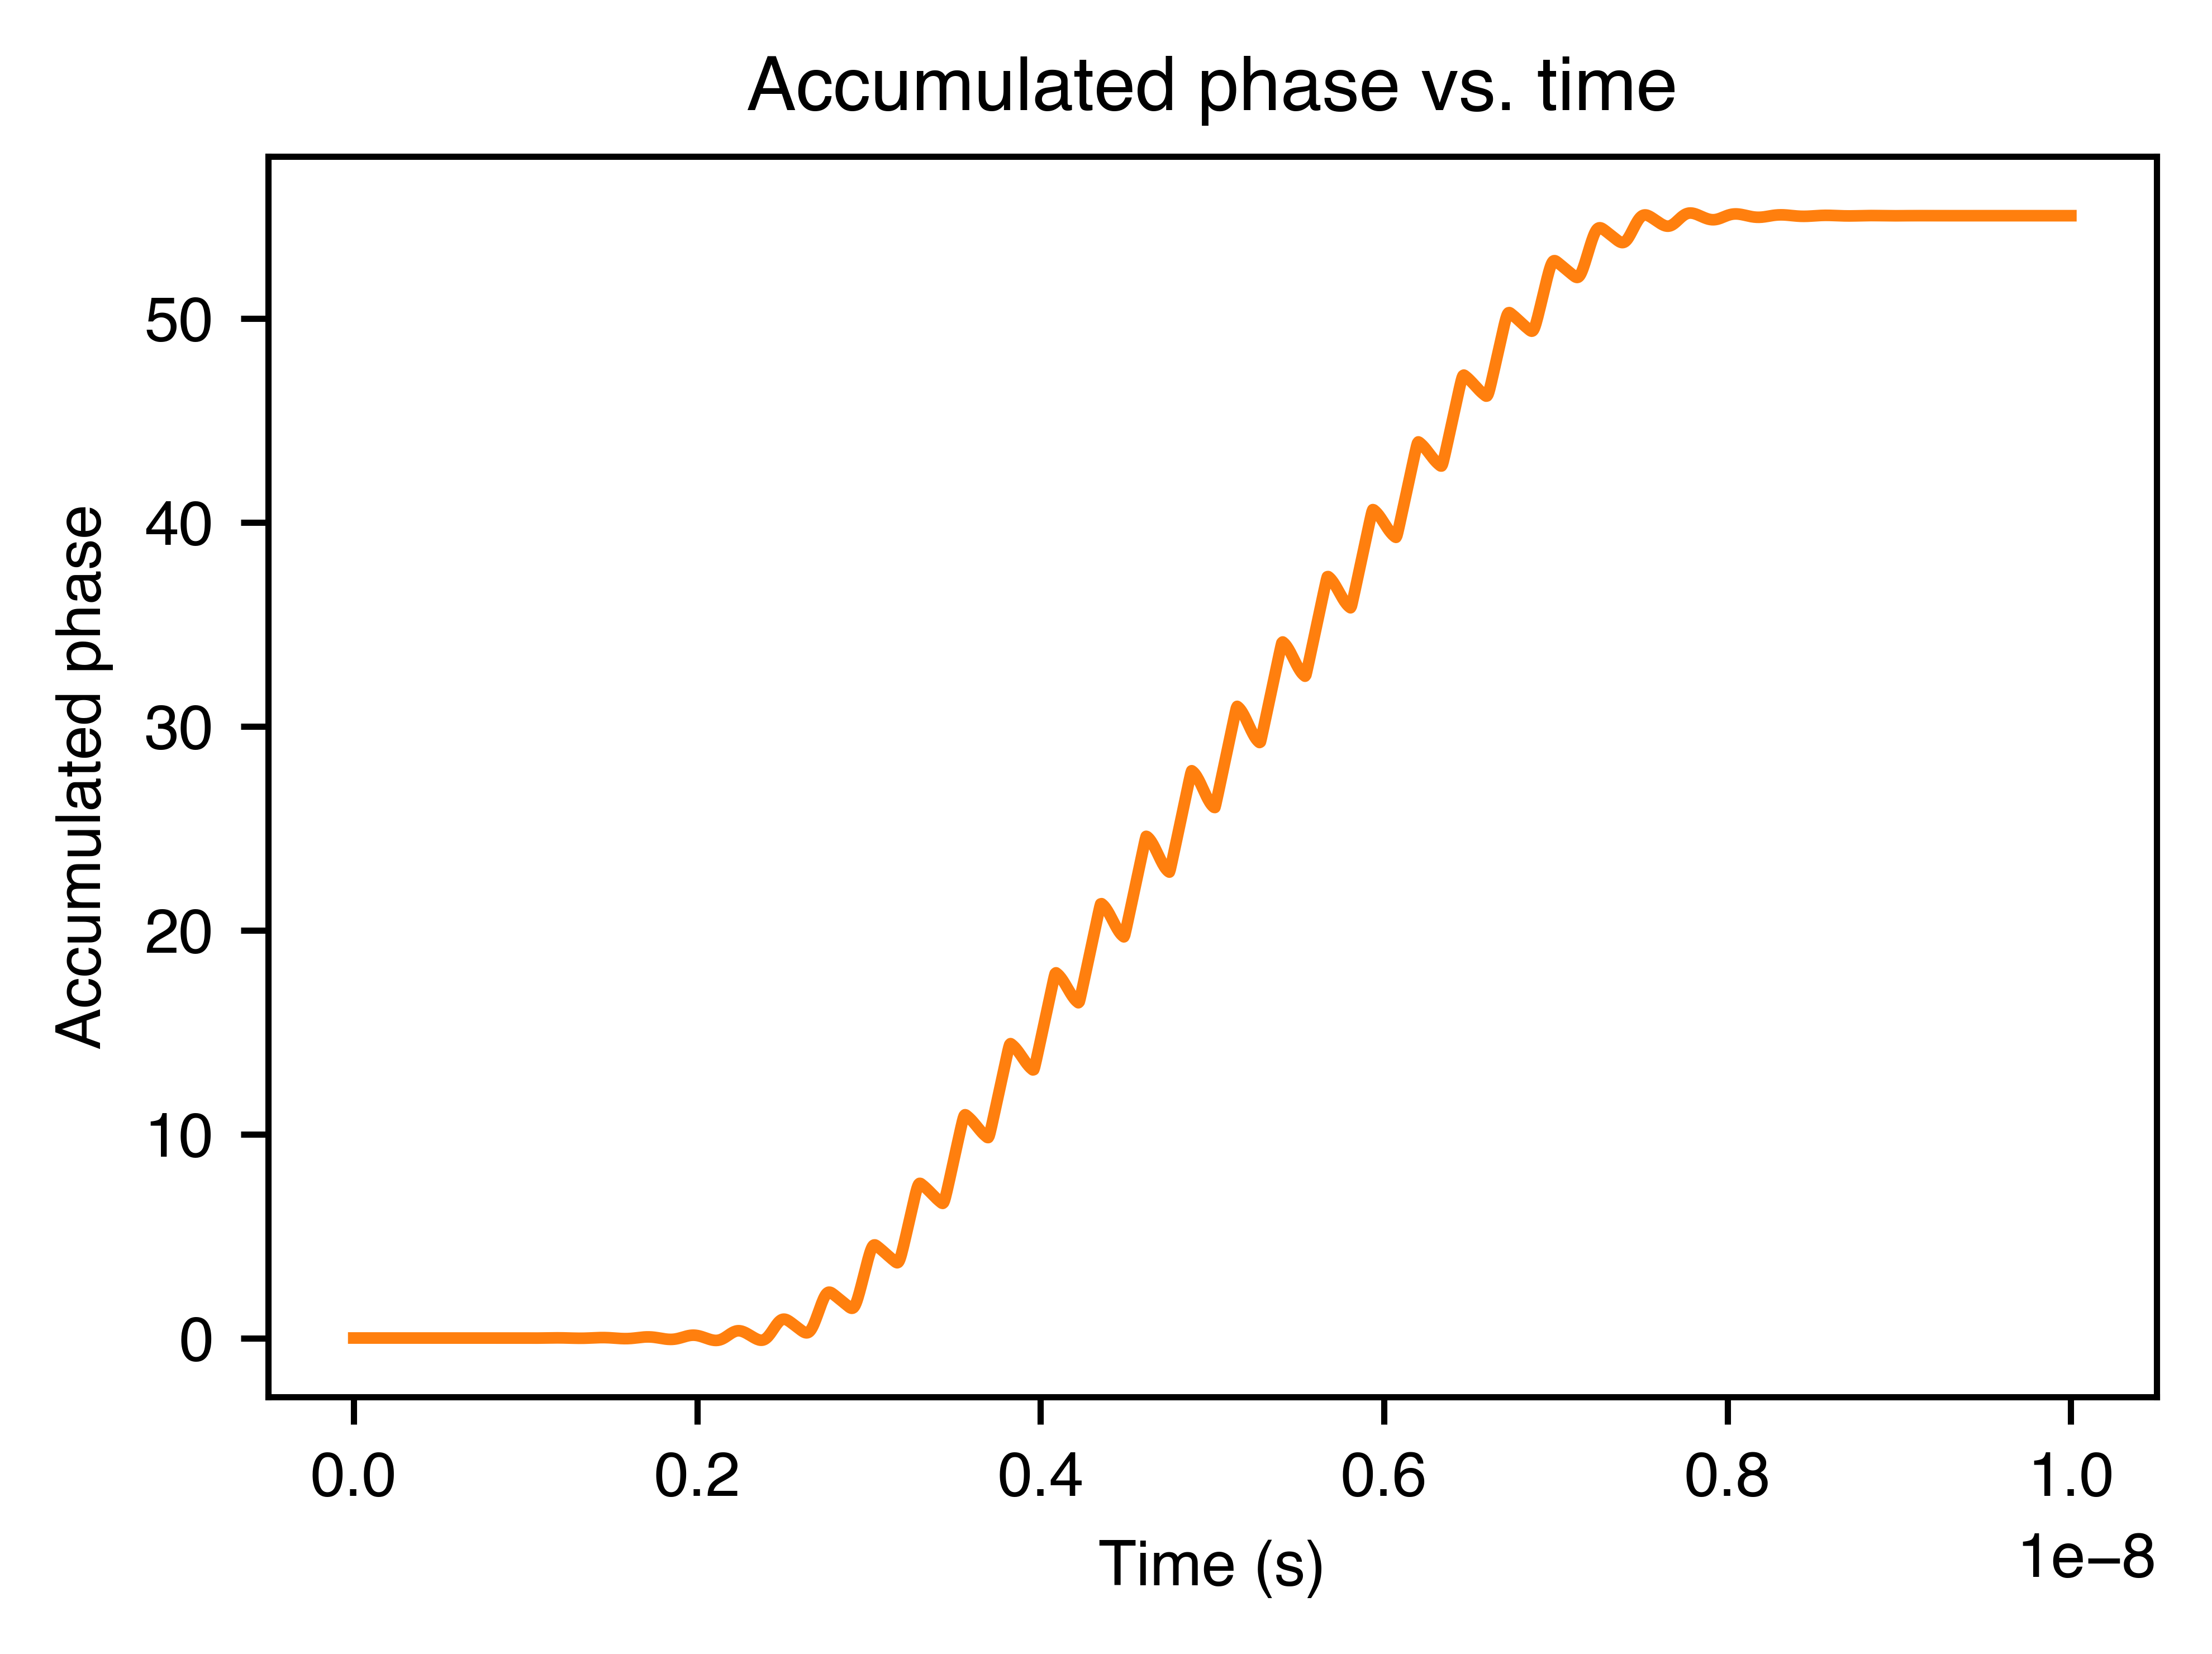

In [76]:
# Not sure I'm computing phase correctly. I'll try a different way.
accPhi01 = np.zeros(nTimes+1)
accPhi01[0] = 0
for i in tqdm(range(nTimes)):
    hTot = h + hDrive(pulseVals[i+1], rabiMatEl)
    eigVals, eigVecs = scipy.linalg.eigh(hTot)
    omega01 = 2*np.pi*(eigVals[1] - eigVals[0]) # Drive frequency
    domega01 = omega01-omegaD
    accPhi01[i+1] = domega01*dt + accPhi01[i]

fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, accPhi01, label='$\\phi_{10} (t)$', color='C1')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accumulated phase')
# ax.legend()
ax.set_title('Accumulated phase vs. time')
plt.tight_layout()

# Pulse with drag (optimized for reducing leakage):

## Initialize the Hamiltonian:

In [77]:
# Define the parameters of the simulation:
nLevels = 100 # Number of charge states considered (basis runs from -nLevels to nLevels)
nEnergies = (2*nLevels) + 1
nG = 0 
n = nHat(nLevels)
# EJ = 2*np.pi*10e9 # rad/s
# EC = 2*np.pi*200e6 # rad/s
EJ = 10e9 # Hz
EC = 200e6 # Hz
sigmaGate = 1e-9 # s, variance (sigma) of gaussian pulse (full pulse with is tGate ~ 6*sigmaGate)
theta = np.pi

# Determine the energy eigenvalues and eigenvectors of the bare transmon Hamiltonian:
h = hTransmon(EJ, EC, nG, nLevels)
energyEigVals, energyEigVecs = scipy.linalg.eigh(h)
omegaD = 2*np.pi*(energyEigVals[1] - energyEigVals[0]) # Drive frequency
anharmonicity = (energyEigVals[2]-energyEigVals[1]) - (energyEigVals[1]-energyEigVals[0])

# Write the bare transmon Hamiltonian in the diagonal basis:
h0 = np.matrix(np.diag(2*np.pi*(energyEigVals - energyEigVals[0]))) # Shift the energies so that omega0 = 0

# Write the drive Hamiltonian (without the time-dependent part of the drive) in terms of the diagonal basis:
rabiMatEl = np.matrix(np.zeros((nEnergies, nEnergies)))
for i in range(nEnergies):
    for j in range(nEnergies):
        matEl = (energyEigVecs[:, i].conj().T @ n @ energyEigVecs[:, j])[0,0] # <i|n|j>
        rabiMatEl[i, j] = theta*matEl

/var/folders/m8/gbh7nps52zzfb187_b37kb540000gn/T/ipykernel_67524/1550915497.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  rabiMatEl[i, j] = theta*matEl


## Define the pulse and plot it:

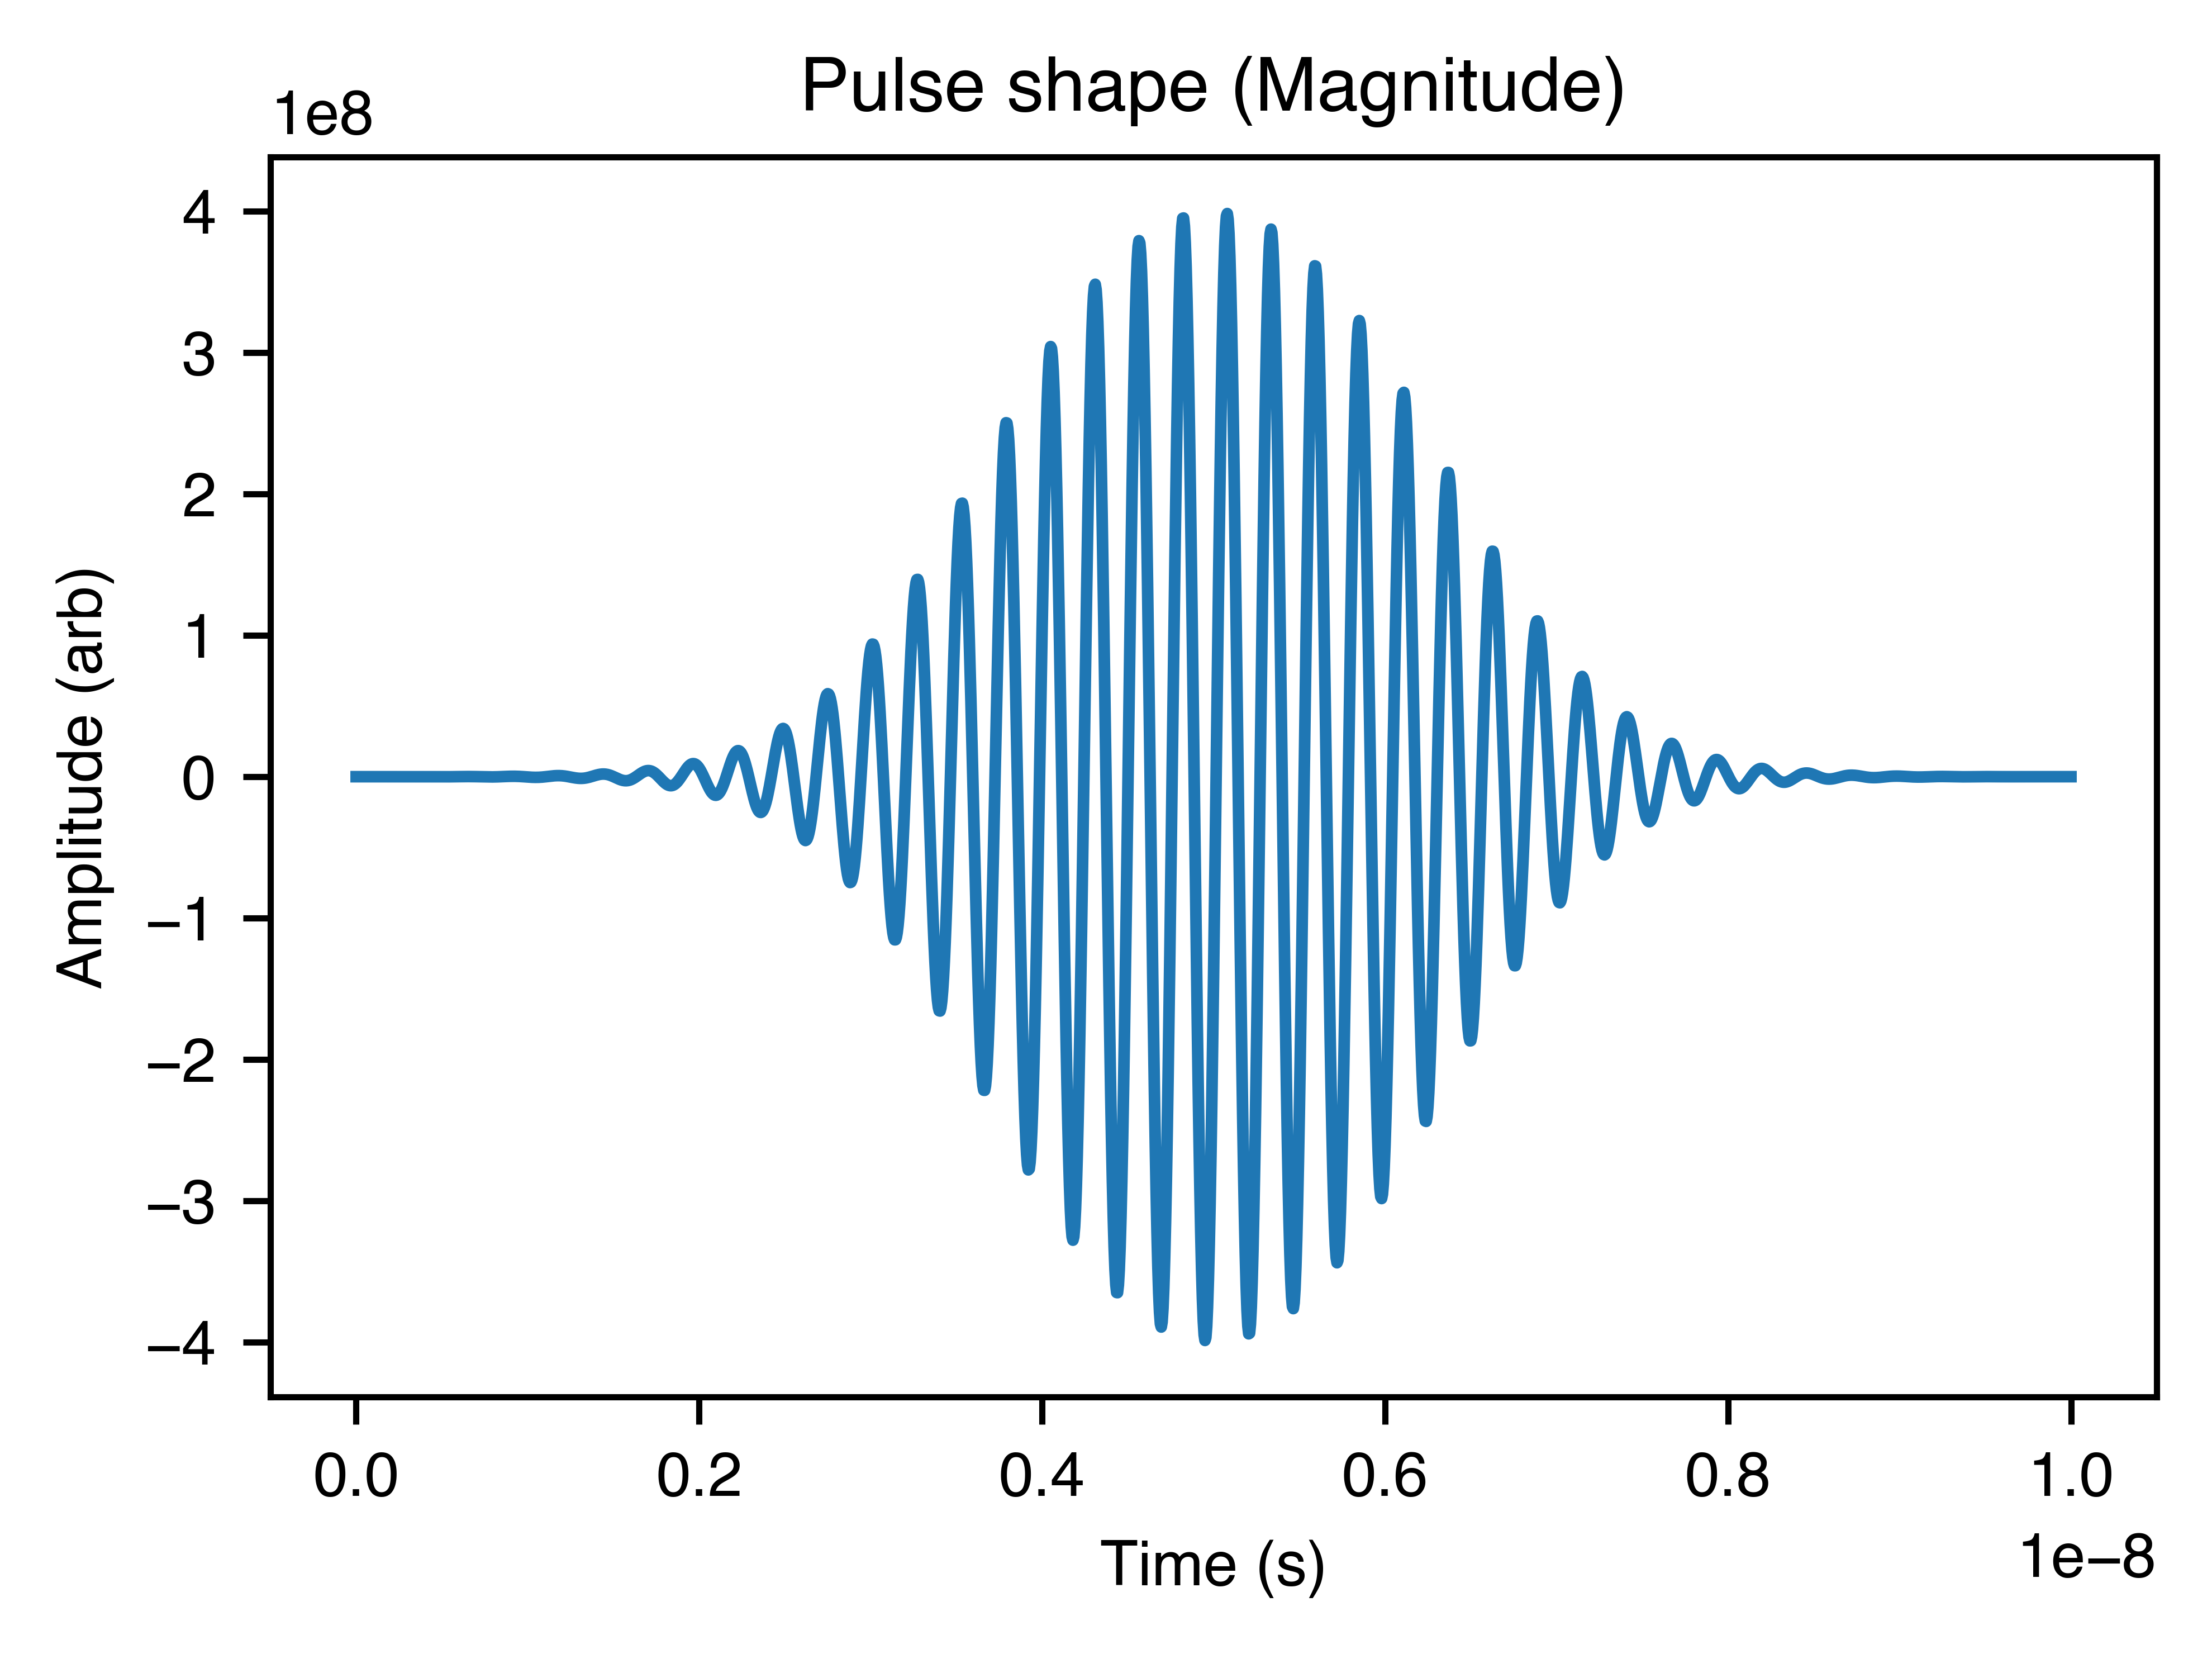

In [78]:
# Pulse parameters:
iAmp = 1
iEnvelope = sGaussian
qAmp = 1/(2*np.pi*anharmonicity)
qEnvelope = sGaussianDerivative
quadArgs = {
    'iArgs': {'sigma': sigmaGate, 'center': 5*sigmaGate},
    'qArgs': {'sigma': sigmaGate, 'center': 5*sigmaGate}
}

# Define the time discretization:
tFinal = 10*sigmaGate
nTimes = 2000
dt = tFinal/nTimes
times = np.linspace(0, tFinal, num=nTimes+1, endpoint=True)
pulseVals = pulse(times, iAmp, iEnvelope, qAmp, qEnvelope, omegaD, quadArgs)

fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, pulseVals)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (Magnitude)')
plt.tight_layout()

### Plot I and Q separately:

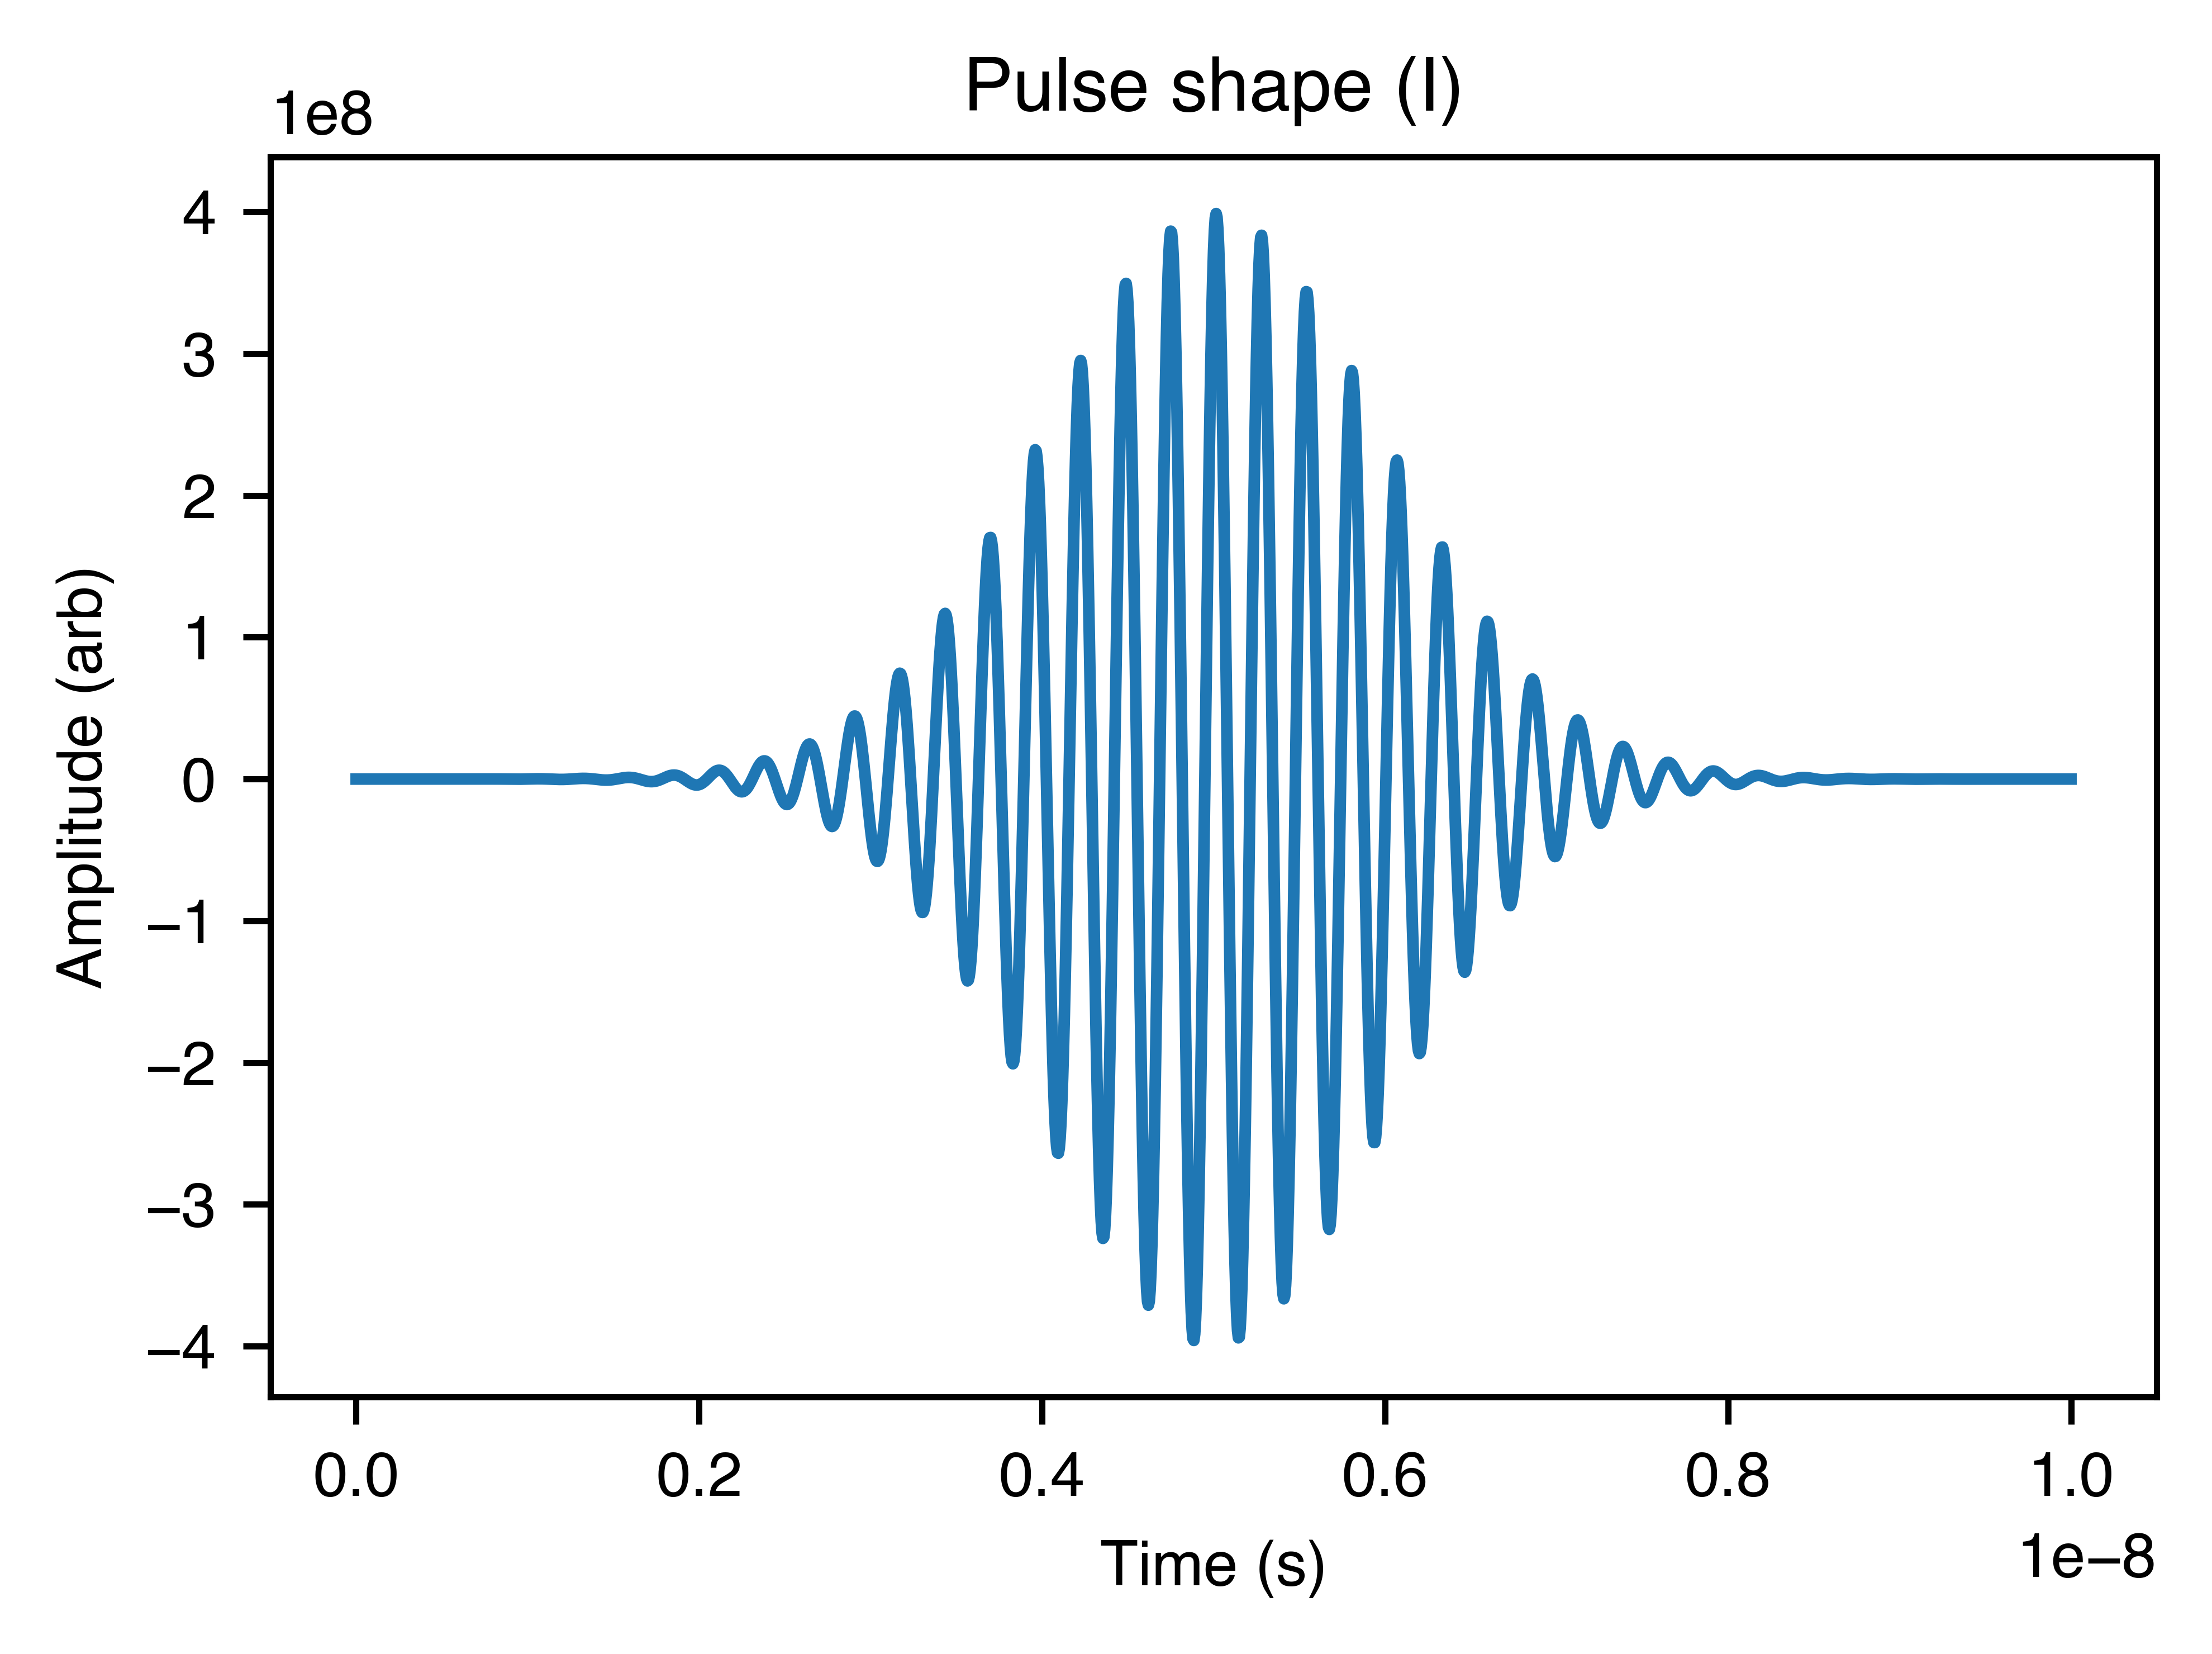

In [79]:
# Code to plot I:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, sGaussian(times, **quadArgs['iArgs'])*np.cos(omegaD*times))
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (I)')
plt.tight_layout()

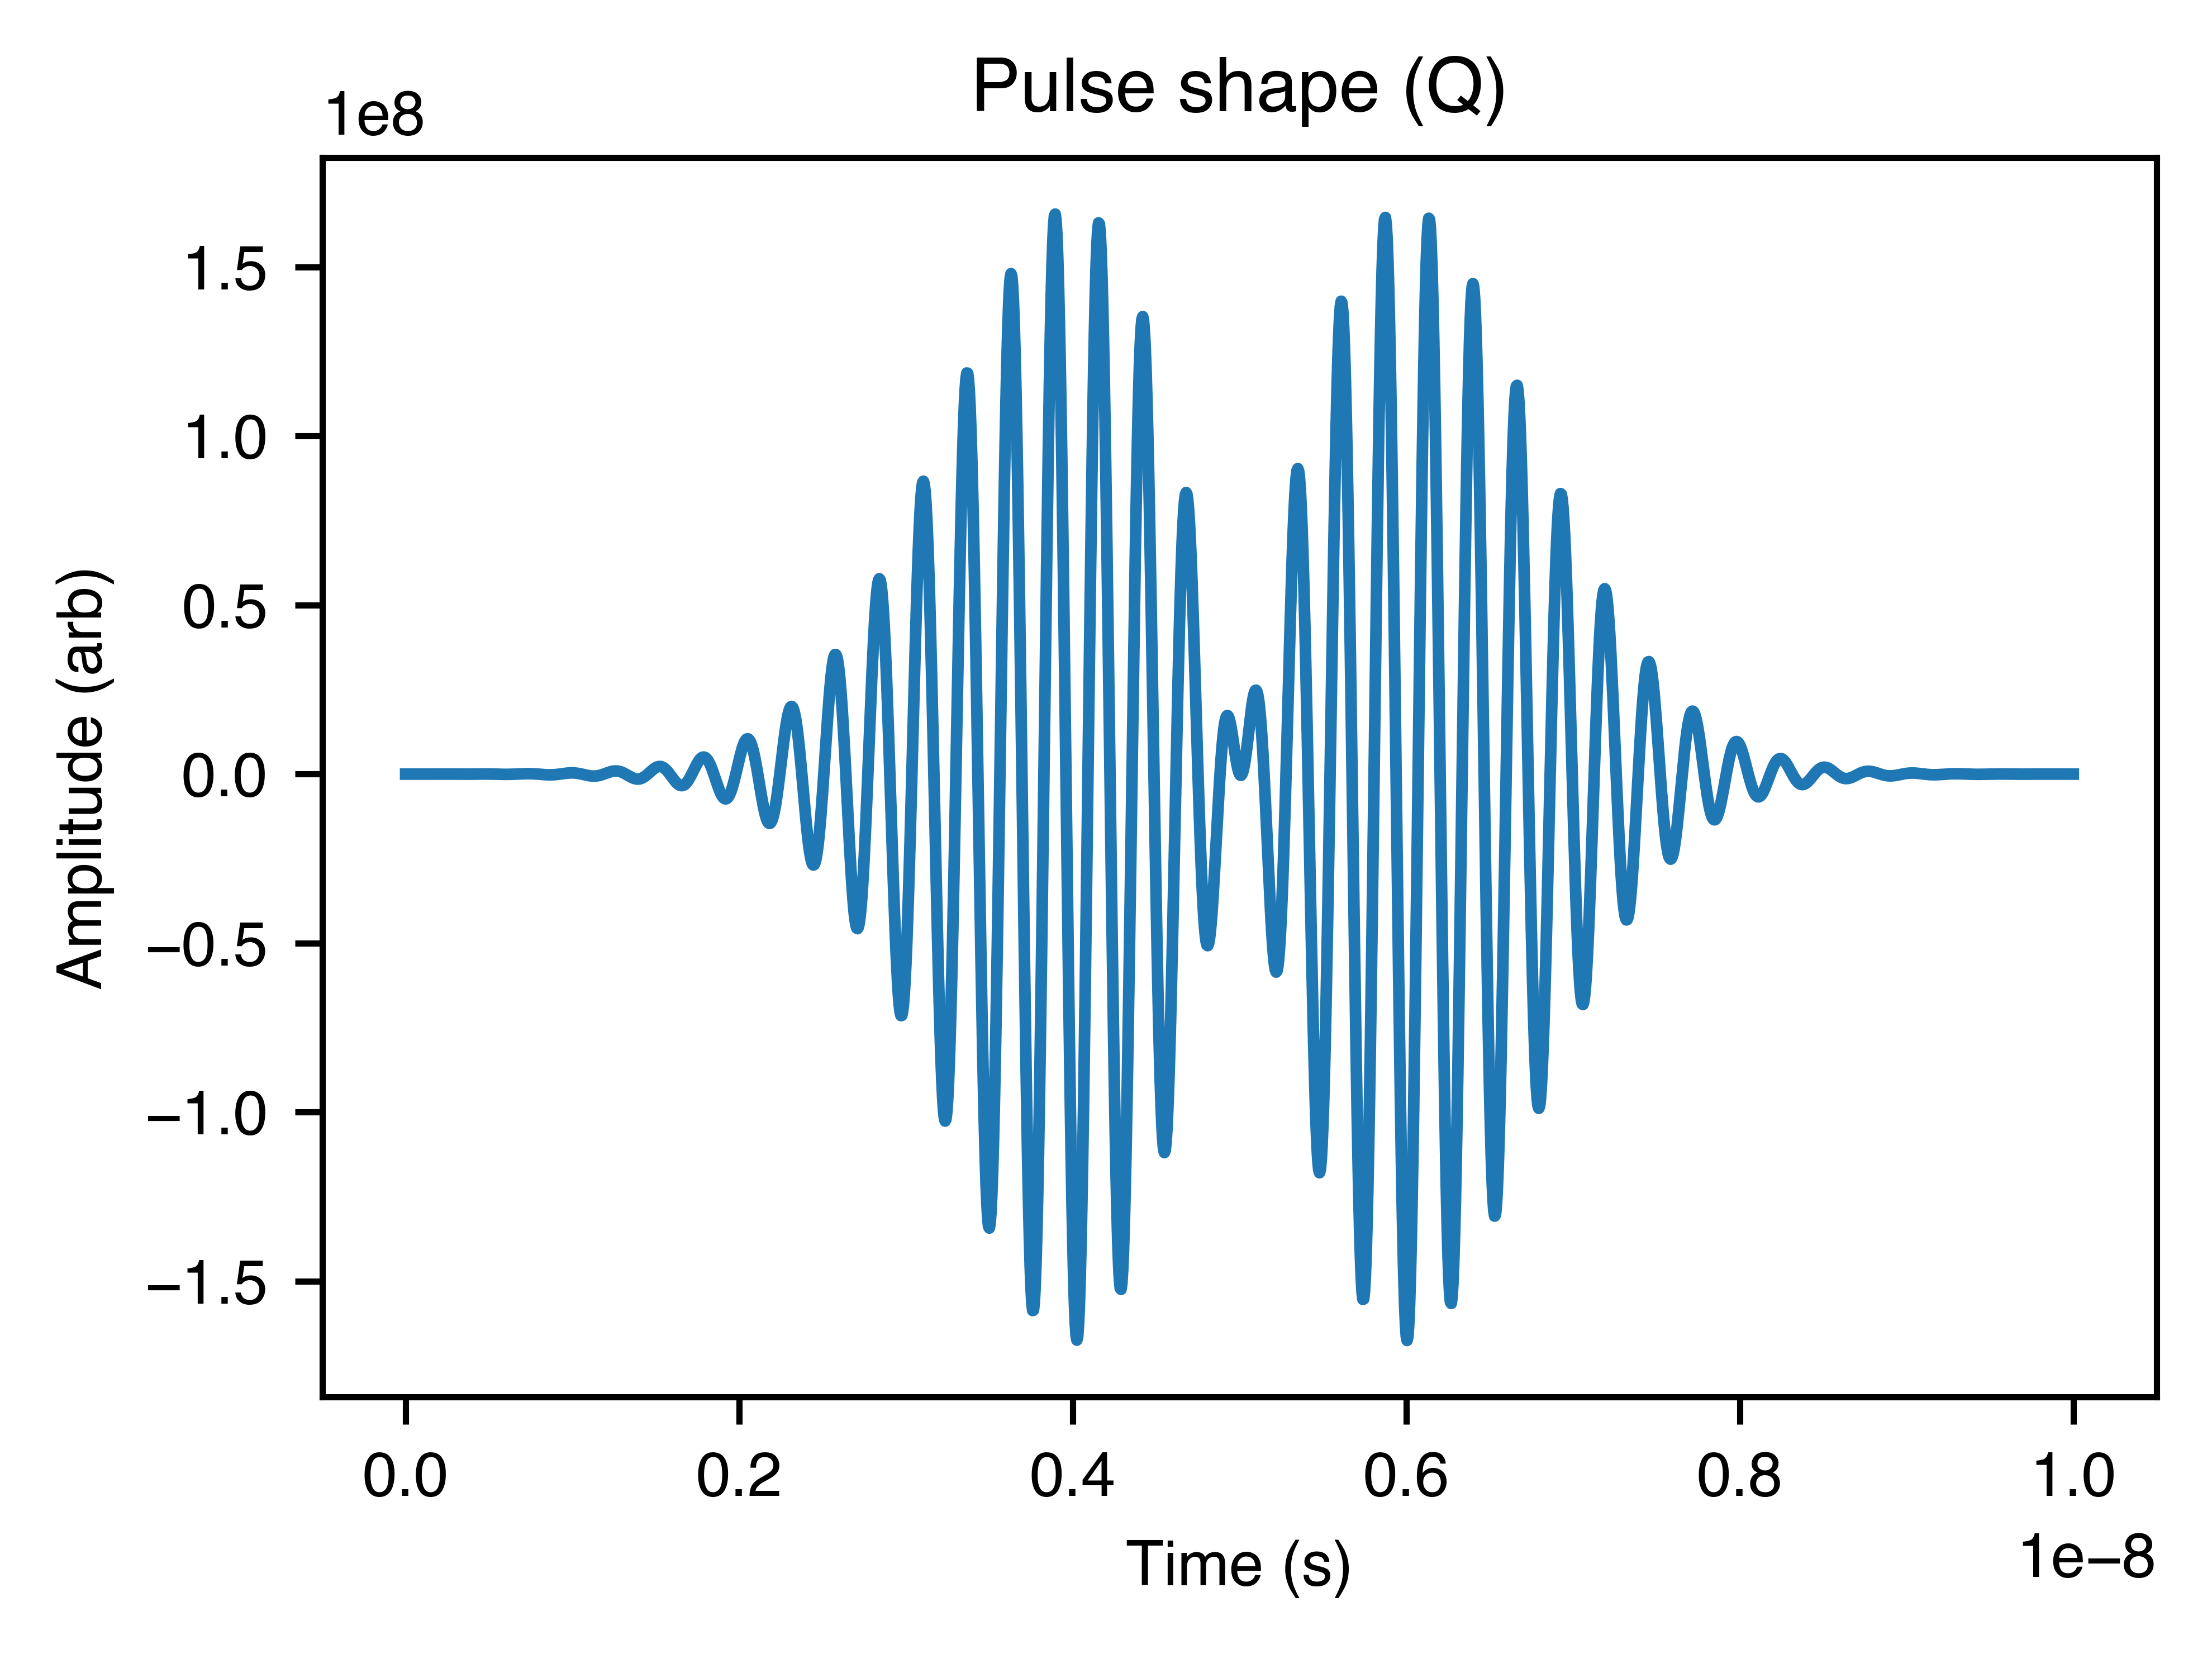

In [80]:
# Code to plot Q:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, (1/(2*np.pi*anharmonicity))*sGaussianDerivative(times, **quadArgs['qArgs'])*np.sin(omegaD*times))
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (Q)')
plt.tight_layout()

## Evolve the system according to the pulse:

In [55]:
# Define the initial state:
psi = np.zeros(nEnergies, dtype=np.complex128)
psi[0] = 1
psi = np.matrix(psi).T

# Define the matrix to contain the state amplitudes vs time:
populations = np.matrix(np.zeros((nEnergies, nTimes+1), dtype=np.complex128))
populations[:,0] = psi

# Evolve the system:
for i in tqdm(range(nTimes)):
    t = dt*(i+1)
    hTildeRF = hDriveRF(h0, pulseVals[i+1], rabiMatEl)
    psi = expm(-1j*hTildeRF*dt) @ psi
    populations[:,i+1] = psi

  0%|                                                                                                  | 0/2000 [00:00<?, ?it/s]/Users/kevindcrowley/opt/anaconda3/lib/python3.9/site-packages/scipy/sparse/linalg/_onenormest.py:154: RuntimeWarning: overflow encountered in true_divide
  Y /= np.abs(Y)
/Users/kevindcrowley/opt/anaconda3/lib/python3.9/site-packages/scipy/sparse/linalg/_onenormest.py:154: RuntimeWarning: invalid value encountered in true_divide
  Y /= np.abs(Y)
  4%|███▉                                                                                     | 88/2000 [00:10<03:54,  8.15it/s]


KeyboardInterrupt: 

In [ ]:
# Plot the results:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
p0 = np.square(np.abs(populations[0, :].A1))
ax.plot(times, p0, label='$p_0$')
p1 = np.square(np.abs(populations[1, :].A1))
ax.plot(times, p1, label='$p_1$')
p2 = np.square(np.abs(populations[2, :].A1))
ax.plot(times, p2, label='$p_2$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Population')
ax.legend()
ax.set_title('Population vs. time')
plt.tight_layout()

## Compute the phase errors:

100%|█████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [01:58<00:00, 16.93it/s]


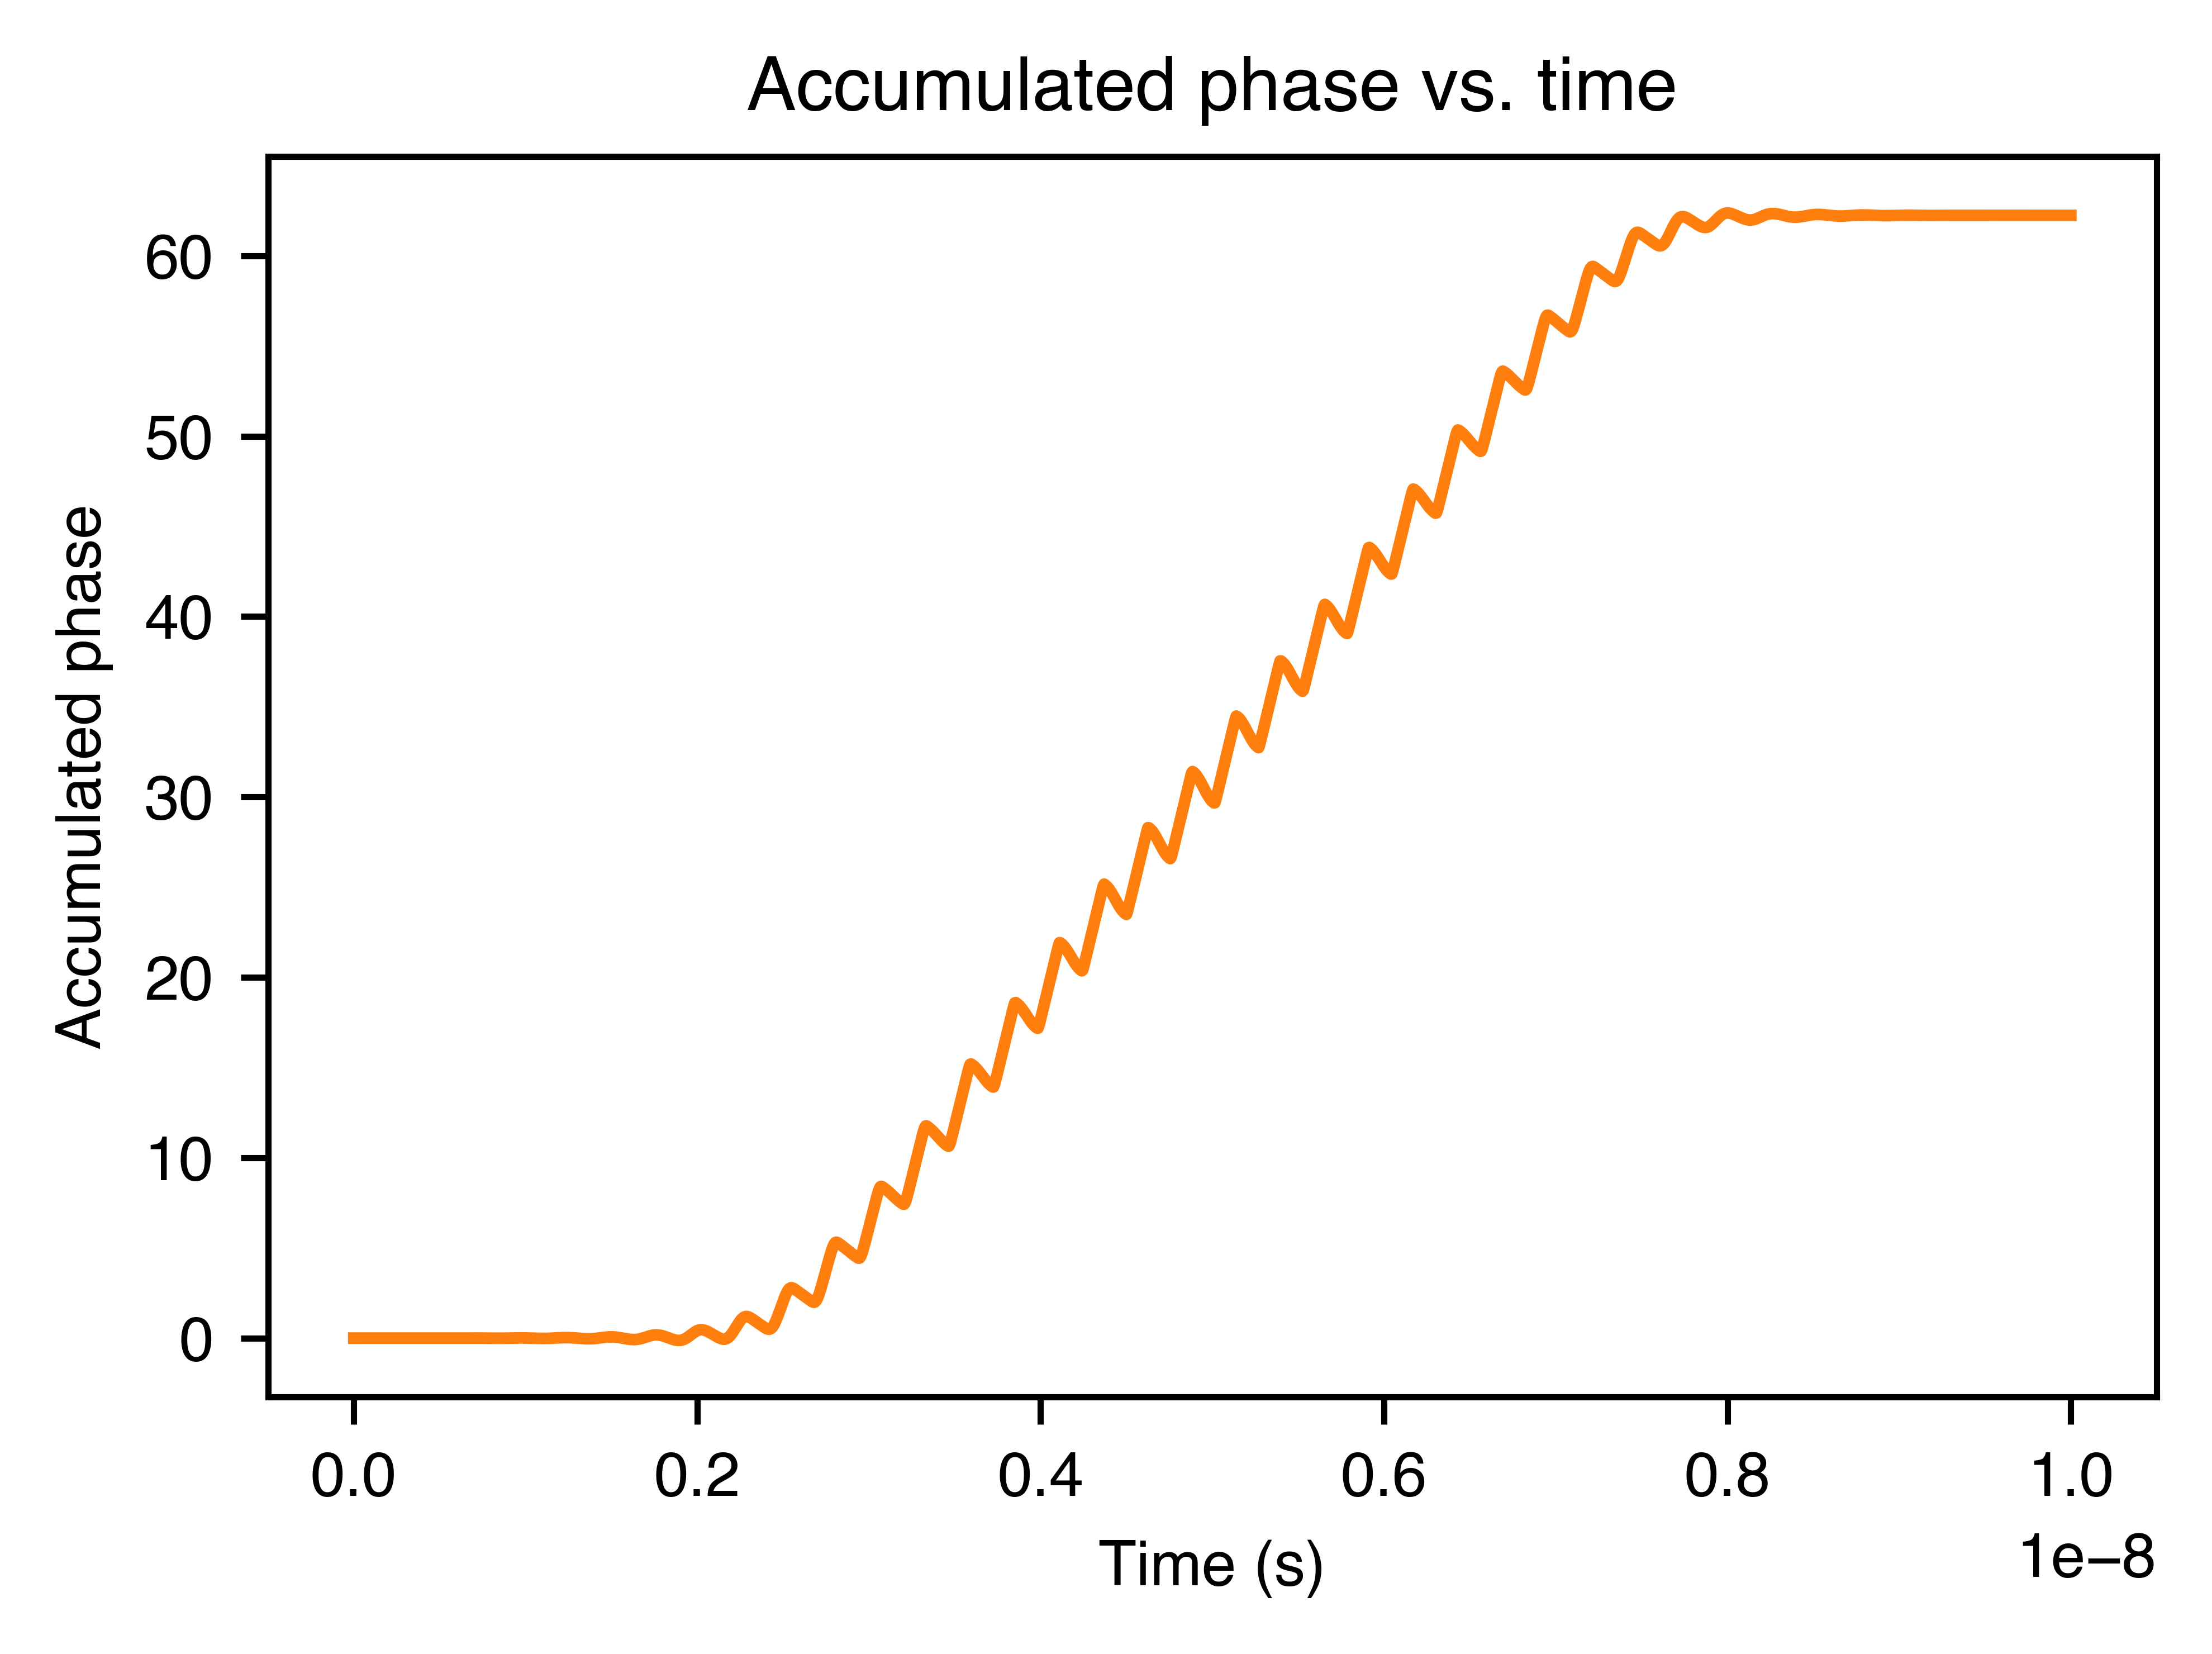

In [81]:
accPhi01 = np.zeros(nTimes+1)
accPhi01[0] = 0
for i in tqdm(range(nTimes)):
    hTot = h + hDrive(pulseVals[i+1], rabiMatEl)
    eigVals, eigVecs = scipy.linalg.eigh(hTot)
    omega01 = 2*np.pi*(eigVals[1] - eigVals[0]) # Drive frequency
    domega01 = omega01-omegaD
    accPhi01[i+1] = domega01*dt + accPhi01[i]

fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, accPhi01, label='$\\phi_{10} (t)$', color='C1')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accumulated phase')
# ax.legend()
ax.set_title('Accumulated phase vs. time')
plt.tight_layout()

# Pulse with drag (optimized for reducing phase error):

## Initialize the Hamiltonian:

In [82]:
# Define the parameters of the simulation:
nLevels = 100 # Number of charge states considered (basis runs from -nLevels to nLevels)
nEnergies = (2*nLevels) + 1
nG = 0 
n = nHat(nLevels)
# EJ = 2*np.pi*10e9 # rad/s
# EC = 2*np.pi*200e6 # rad/s
EJ = 10e9 # Hz
EC = 200e6 # Hz
sigmaGate = 1e-9 # s, variance (sigma) of gaussian pulse (full pulse with is tGate ~ 6*sigmaGate)
theta = np.pi

# Determine the energy eigenvalues and eigenvectors of the bare transmon Hamiltonian:
h = hTransmon(EJ, EC, nG, nLevels)
energyEigVals, energyEigVecs = scipy.linalg.eigh(h)
omegaD = 2*np.pi*(energyEigVals[1] - energyEigVals[0]) # Drive frequency
anharmonicity = (energyEigVals[2]-energyEigVals[1]) - (energyEigVals[1]-energyEigVals[0])

# Write the bare transmon Hamiltonian in the diagonal basis:
h0 = np.matrix(np.diag(2*np.pi*(energyEigVals - energyEigVals[0]))) # Shift the energies so that omega0 = 0

# Write the drive Hamiltonian (without the time-dependent part of the drive) in terms of the diagonal basis:
rabiMatEl = np.matrix(np.zeros((nEnergies, nEnergies)))
for i in range(nEnergies):
    for j in range(nEnergies):
        matEl = (energyEigVecs[:, i].conj().T @ n @ energyEigVecs[:, j])[0,0] # <i|n|j>
        rabiMatEl[i, j] = theta*matEl

/var/folders/m8/gbh7nps52zzfb187_b37kb540000gn/T/ipykernel_67524/1550915497.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  rabiMatEl[i, j] = theta*matEl


## Define the pulse and plot it:

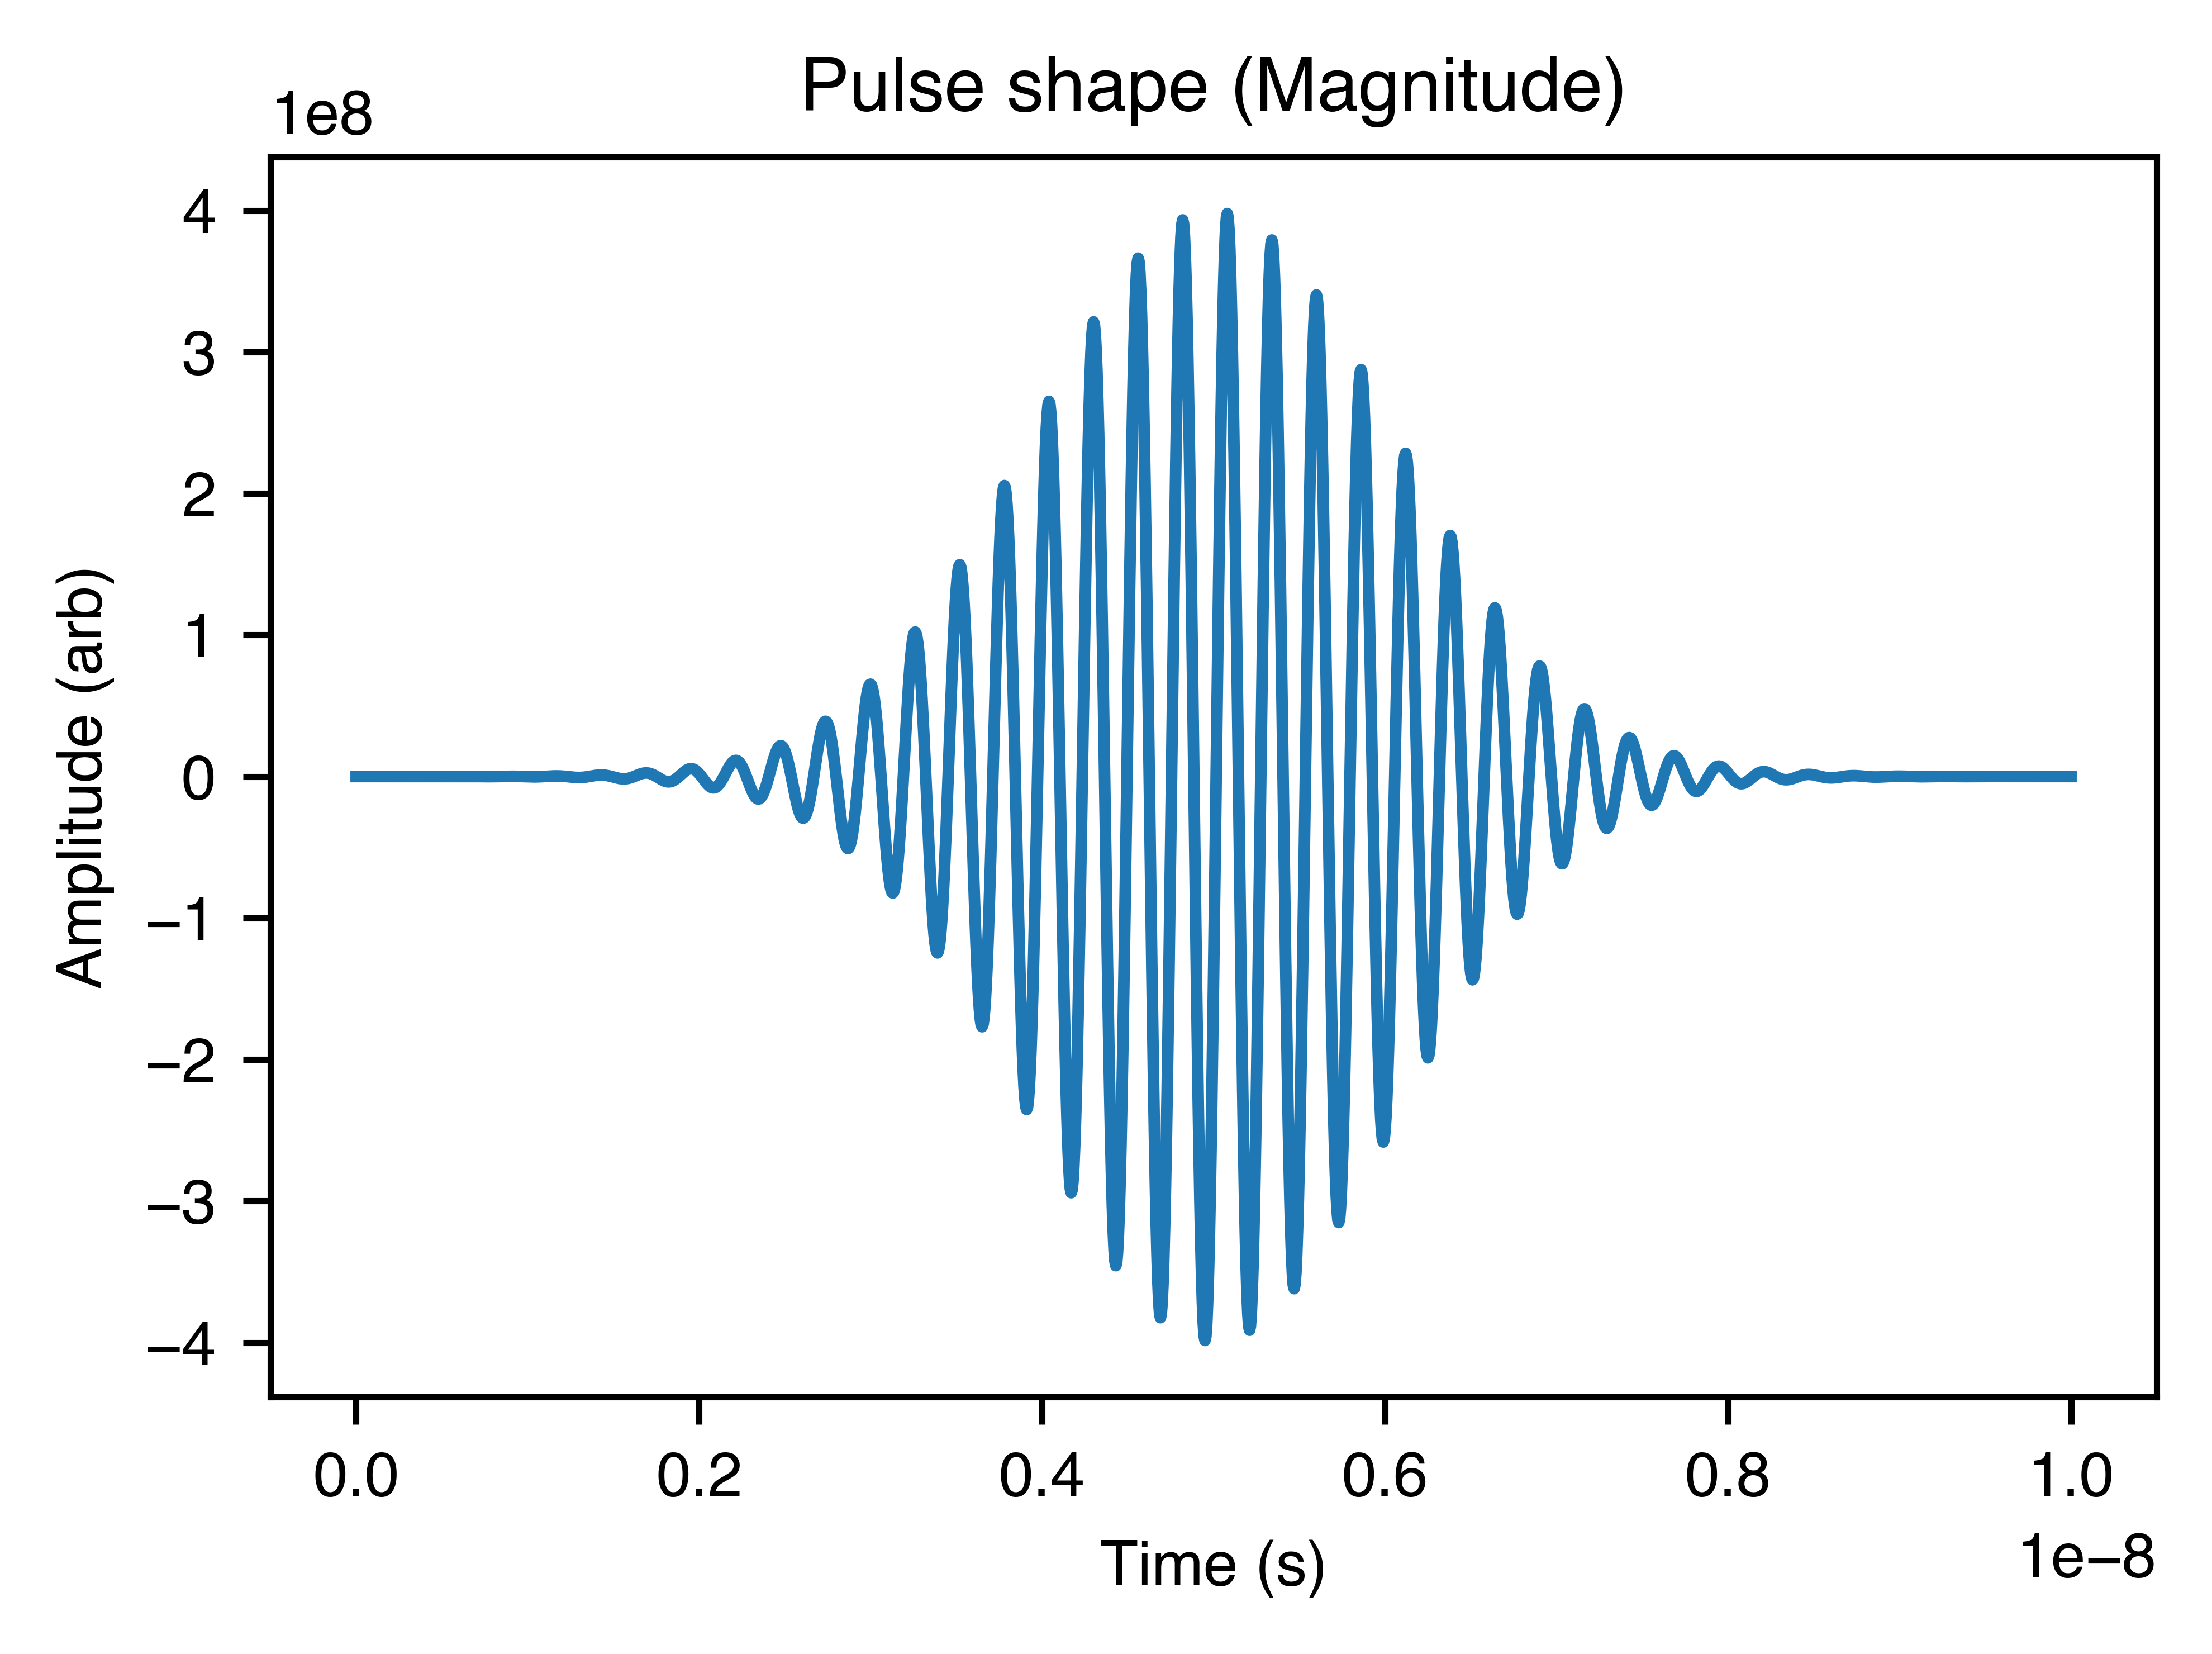

In [87]:
# Pulse parameters:
iAmp = 1
iEnvelope = sGaussian
qAmp = 0.5/(2*np.pi*anharmonicity)
qEnvelope = sGaussianDerivative
quadArgs = {
    'iArgs': {'sigma': sigmaGate, 'center': 5*sigmaGate},
    'qArgs': {'sigma': sigmaGate, 'center': 5*sigmaGate}
}

# Define the time discretization:
tFinal = 10*sigmaGate
nTimes = 2000
dt = tFinal/nTimes
times = np.linspace(0, tFinal, num=nTimes+1, endpoint=True)
pulseVals = pulse(times, iAmp, iEnvelope, qAmp, qEnvelope, omegaD, quadArgs)

fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, pulseVals)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (Magnitude)')
plt.tight_layout()

### Plot I and Q separately:

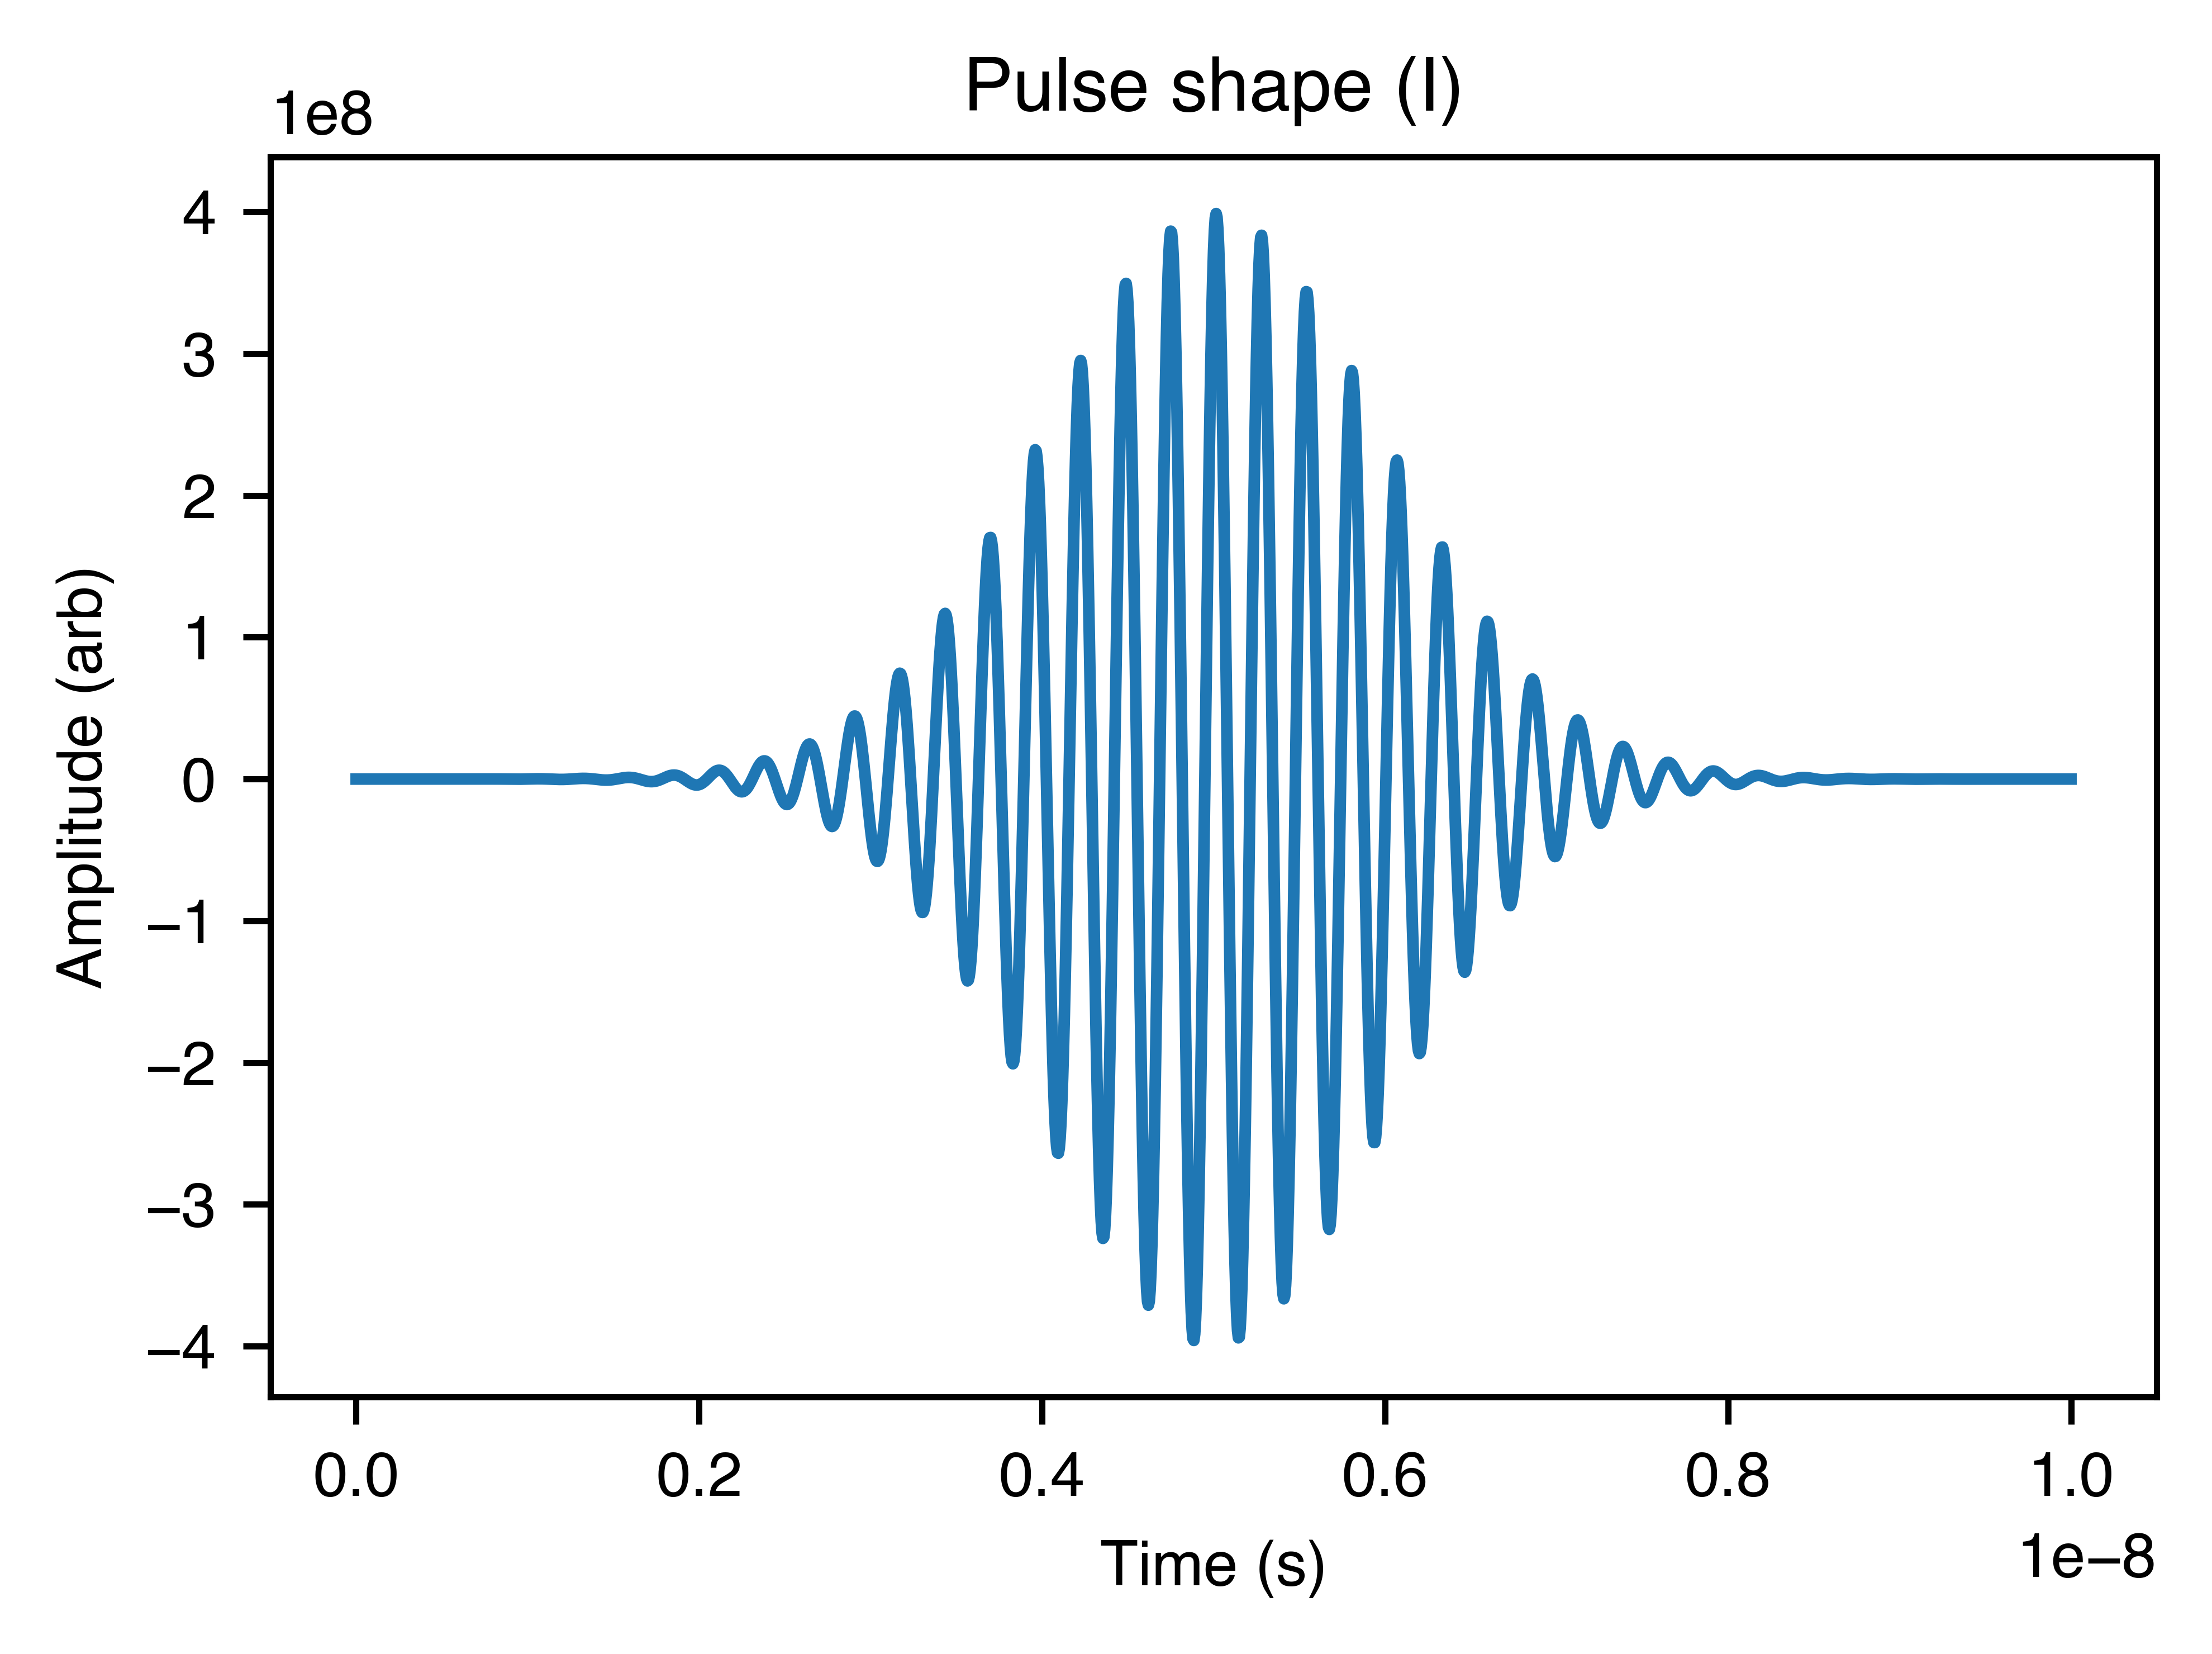

In [88]:
# Code to plot I:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, sGaussian(times, **quadArgs['iArgs'])*np.cos(omegaD*times))
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (I)')
plt.tight_layout()

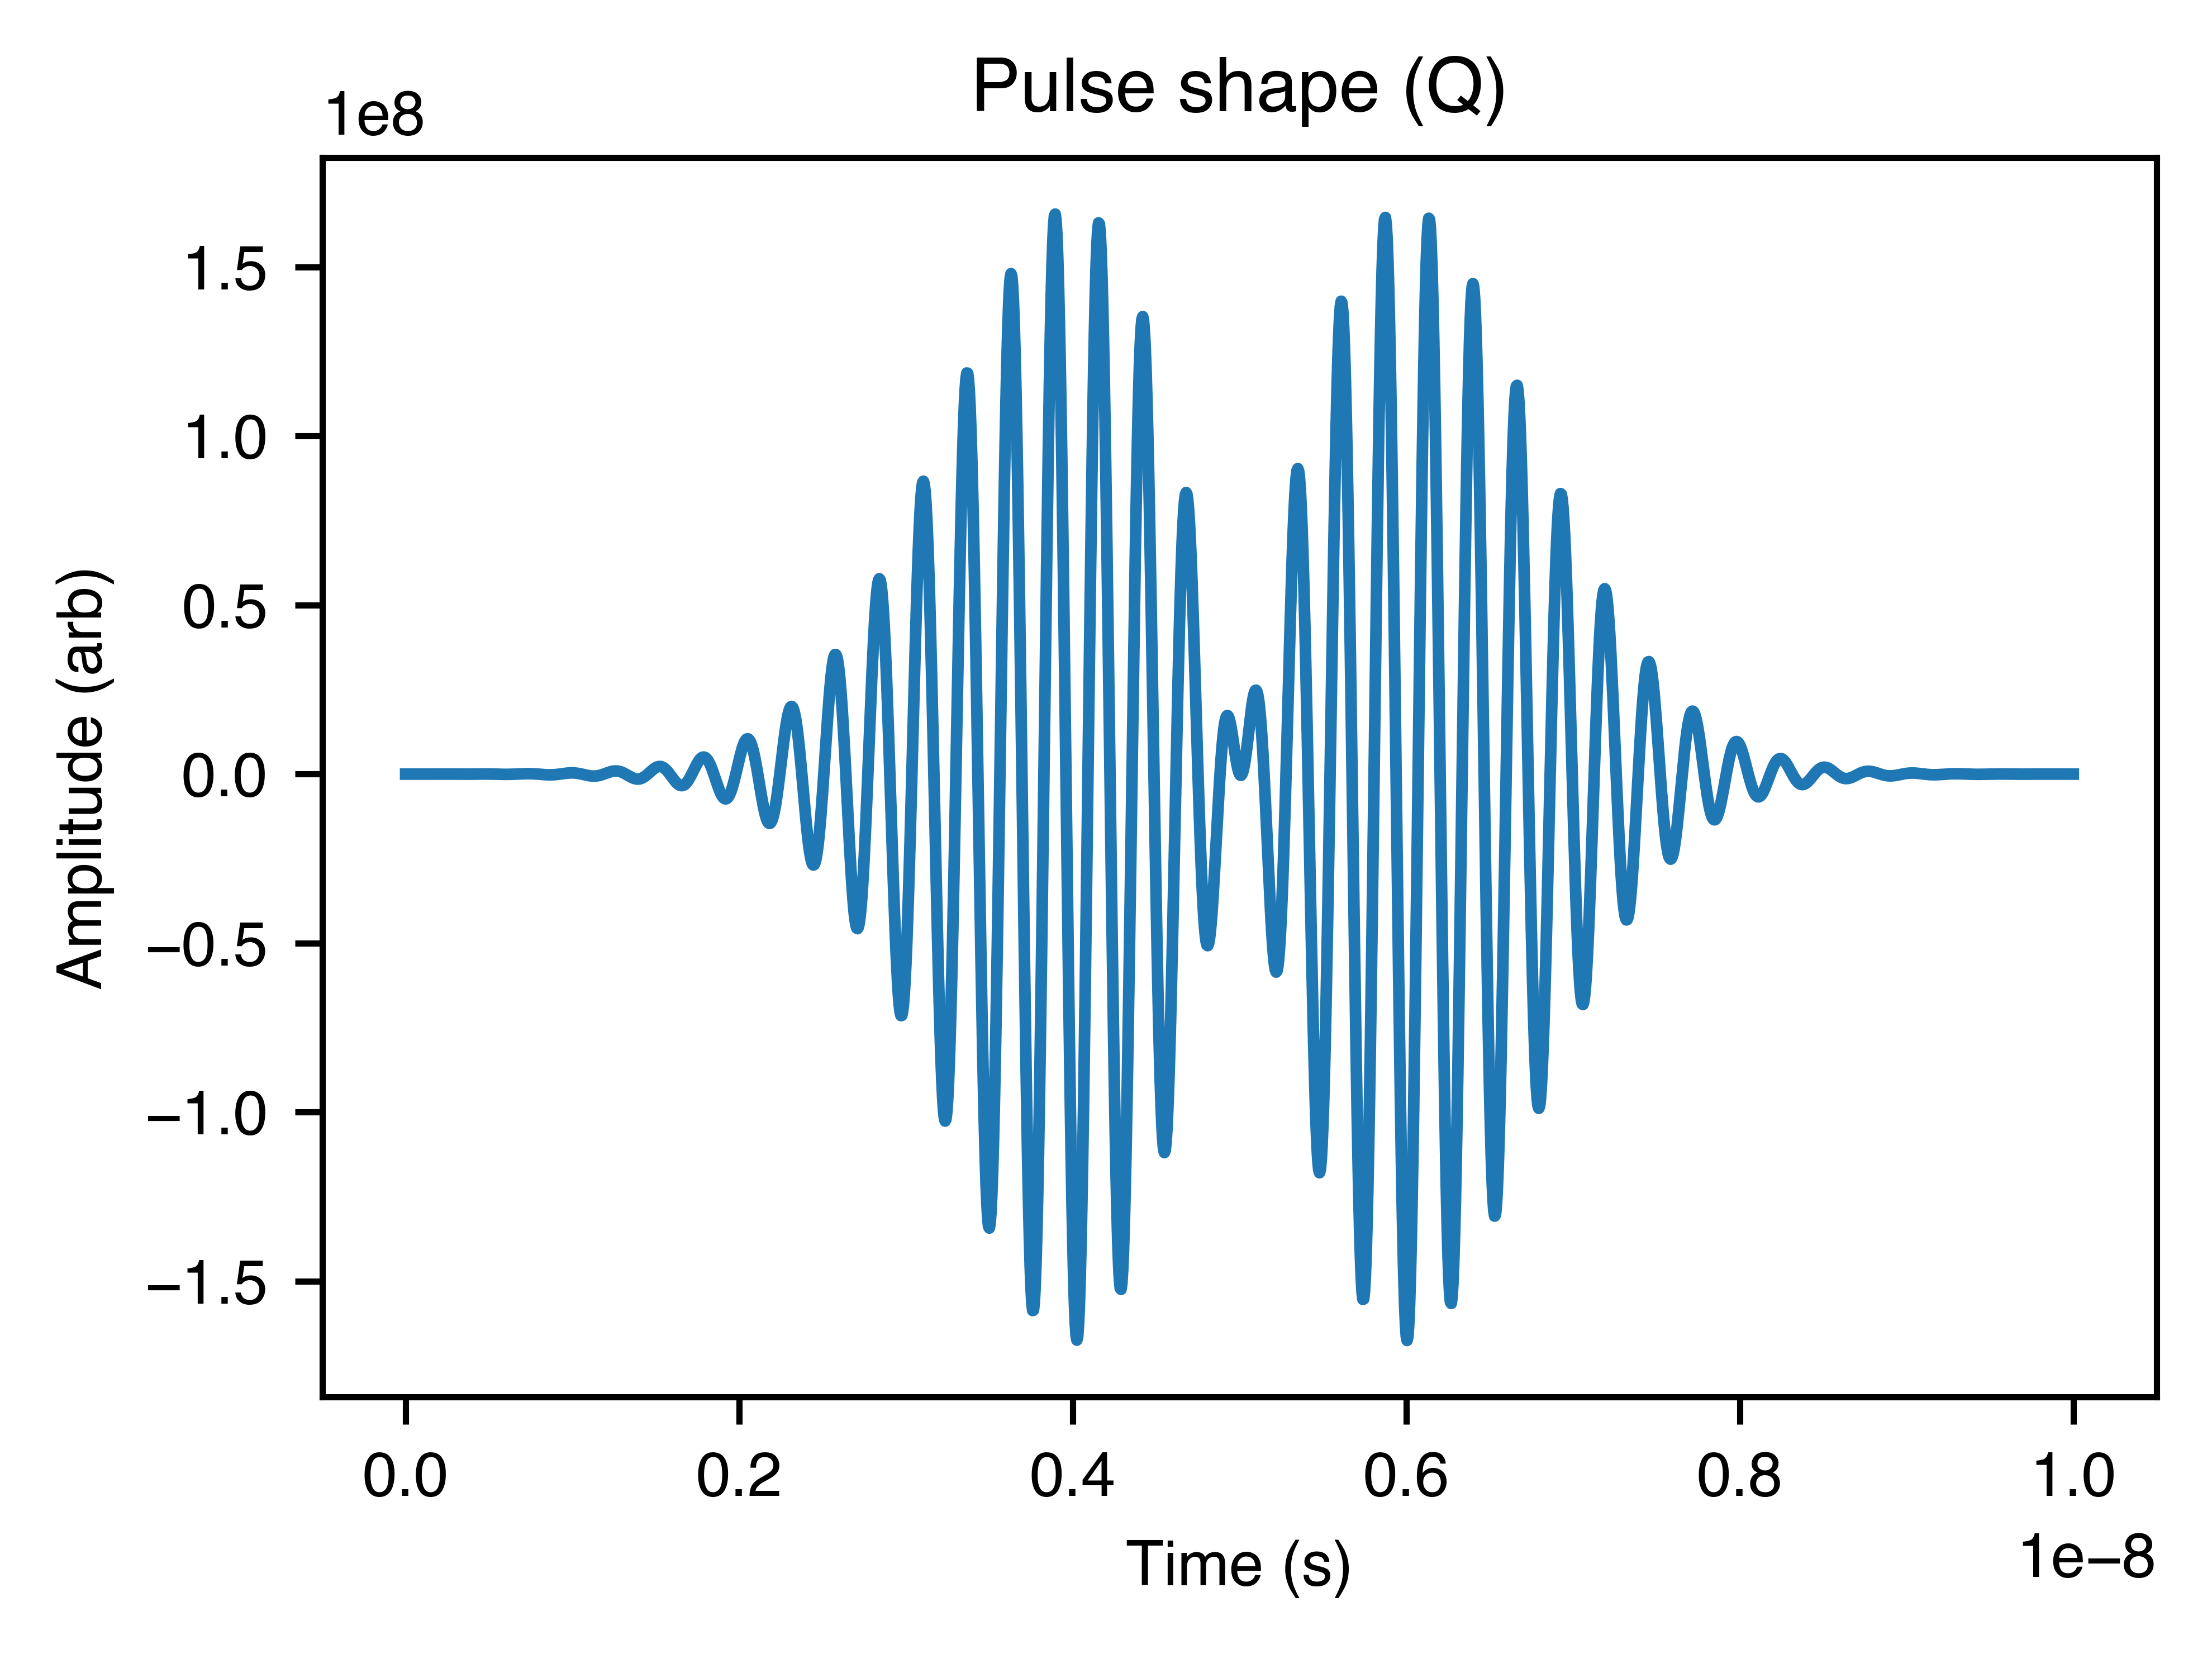

In [89]:
# Code to plot Q:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, (1/(2*np.pi*anharmonicity))*sGaussianDerivative(times, **quadArgs['qArgs'])*np.sin(omegaD*times))
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (arb)')
ax.set_title('Pulse shape (Q)')
plt.tight_layout()

## Evolve the system according to the pulse:

In [90]:
# Define the initial state:
psi = np.zeros(nEnergies, dtype=np.complex128)
psi[0] = 1
psi = np.matrix(psi).T

# Define the matrix to contain the state amplitudes vs time:
populations = np.matrix(np.zeros((nEnergies, nTimes+1), dtype=np.complex128))
populations[:,0] = psi

# Evolve the system:
for i in tqdm(range(nTimes)):
    t = dt*(i+1)
    hTildeRF = hDriveRF(h0, pulseVals[i+1], rabiMatEl)
    psi = expm(-1j*hTildeRF*dt) @ psi
    populations[:,i+1] = psi

  0%|                                                                                                    | 0/2000 [00:00<?, ?it/s]/Users/kevindcrowley/opt/anaconda3/lib/python3.9/site-packages/scipy/sparse/linalg/_onenormest.py:154: RuntimeWarning: overflow encountered in true_divide
  Y /= np.abs(Y)
/Users/kevindcrowley/opt/anaconda3/lib/python3.9/site-packages/scipy/sparse/linalg/_onenormest.py:154: RuntimeWarning: invalid value encountered in true_divide
  Y /= np.abs(Y)
100%|█████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [05:03<00:00,  6.59it/s]


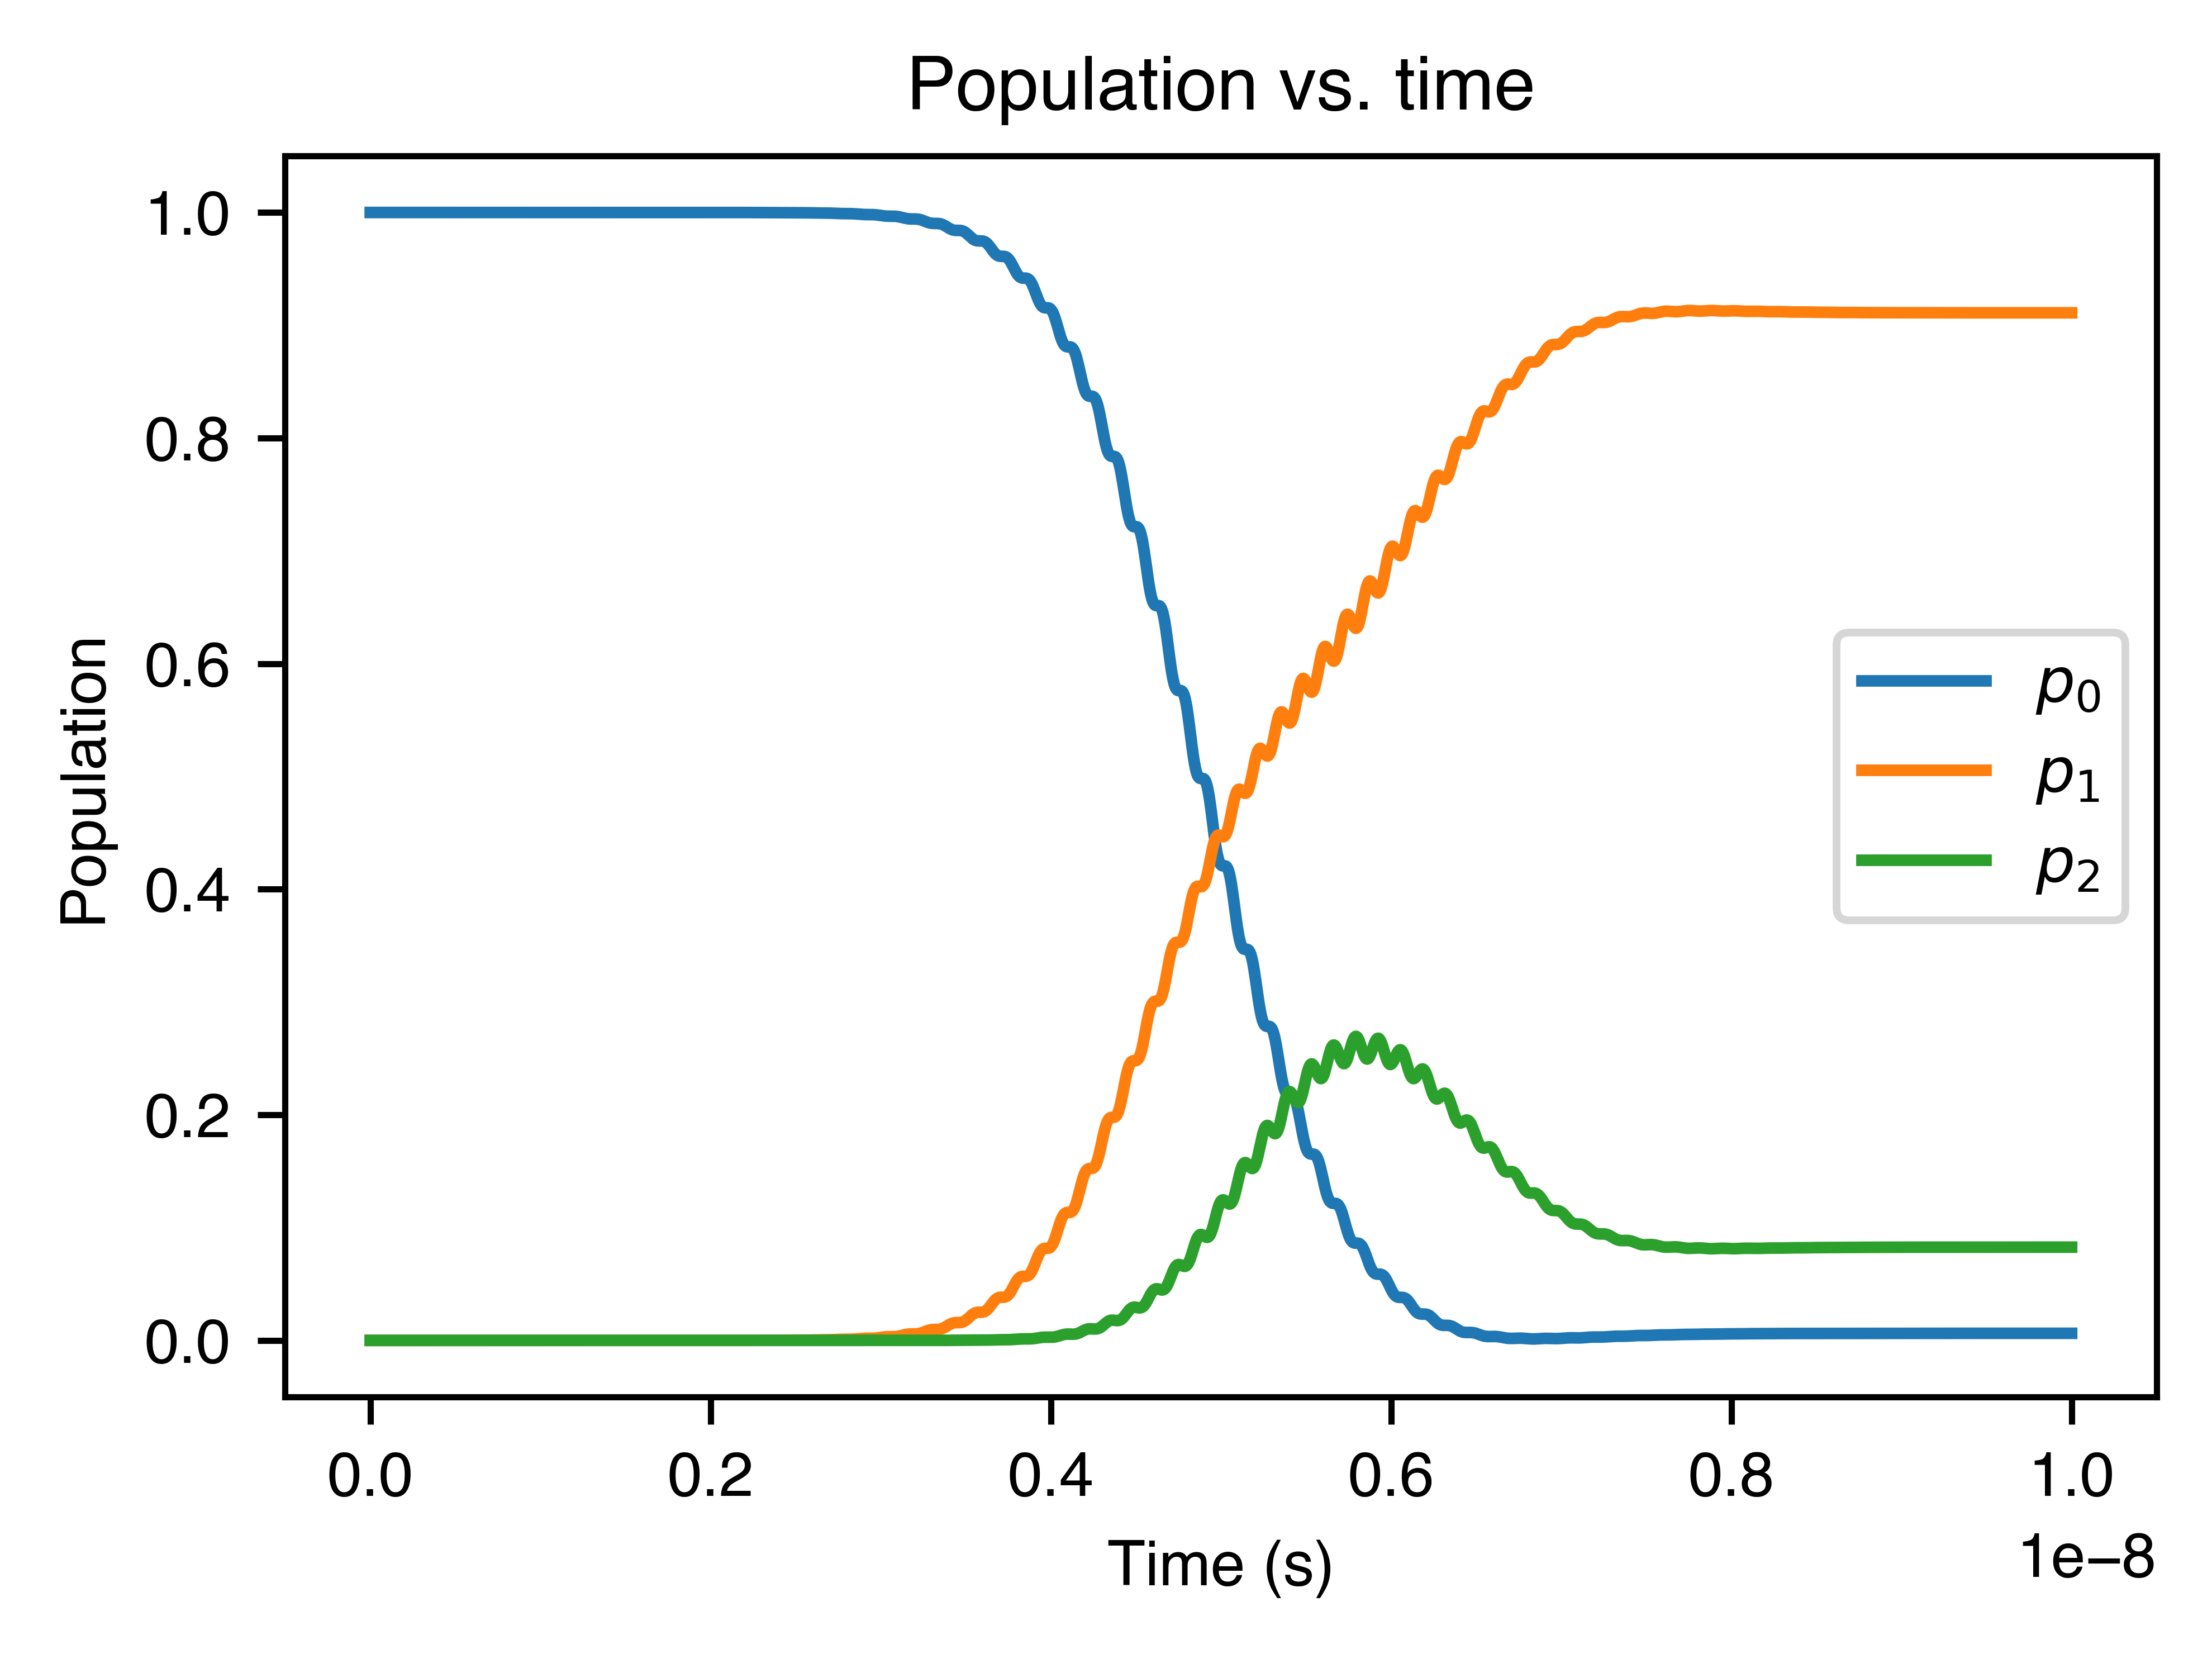

In [91]:
# Plot the results:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
p0 = np.square(np.abs(populations[0, :].A1))
ax.plot(times, p0, label='$p_0$')
p1 = np.square(np.abs(populations[1, :].A1))
ax.plot(times, p1, label='$p_1$')
p2 = np.square(np.abs(populations[2, :].A1))
ax.plot(times, p2, label='$p_2$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Population')
ax.legend()
ax.set_title('Population vs. time')
plt.tight_layout()

## Compute the phase errors:

100%|█████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [01:58<00:00, 16.93it/s]


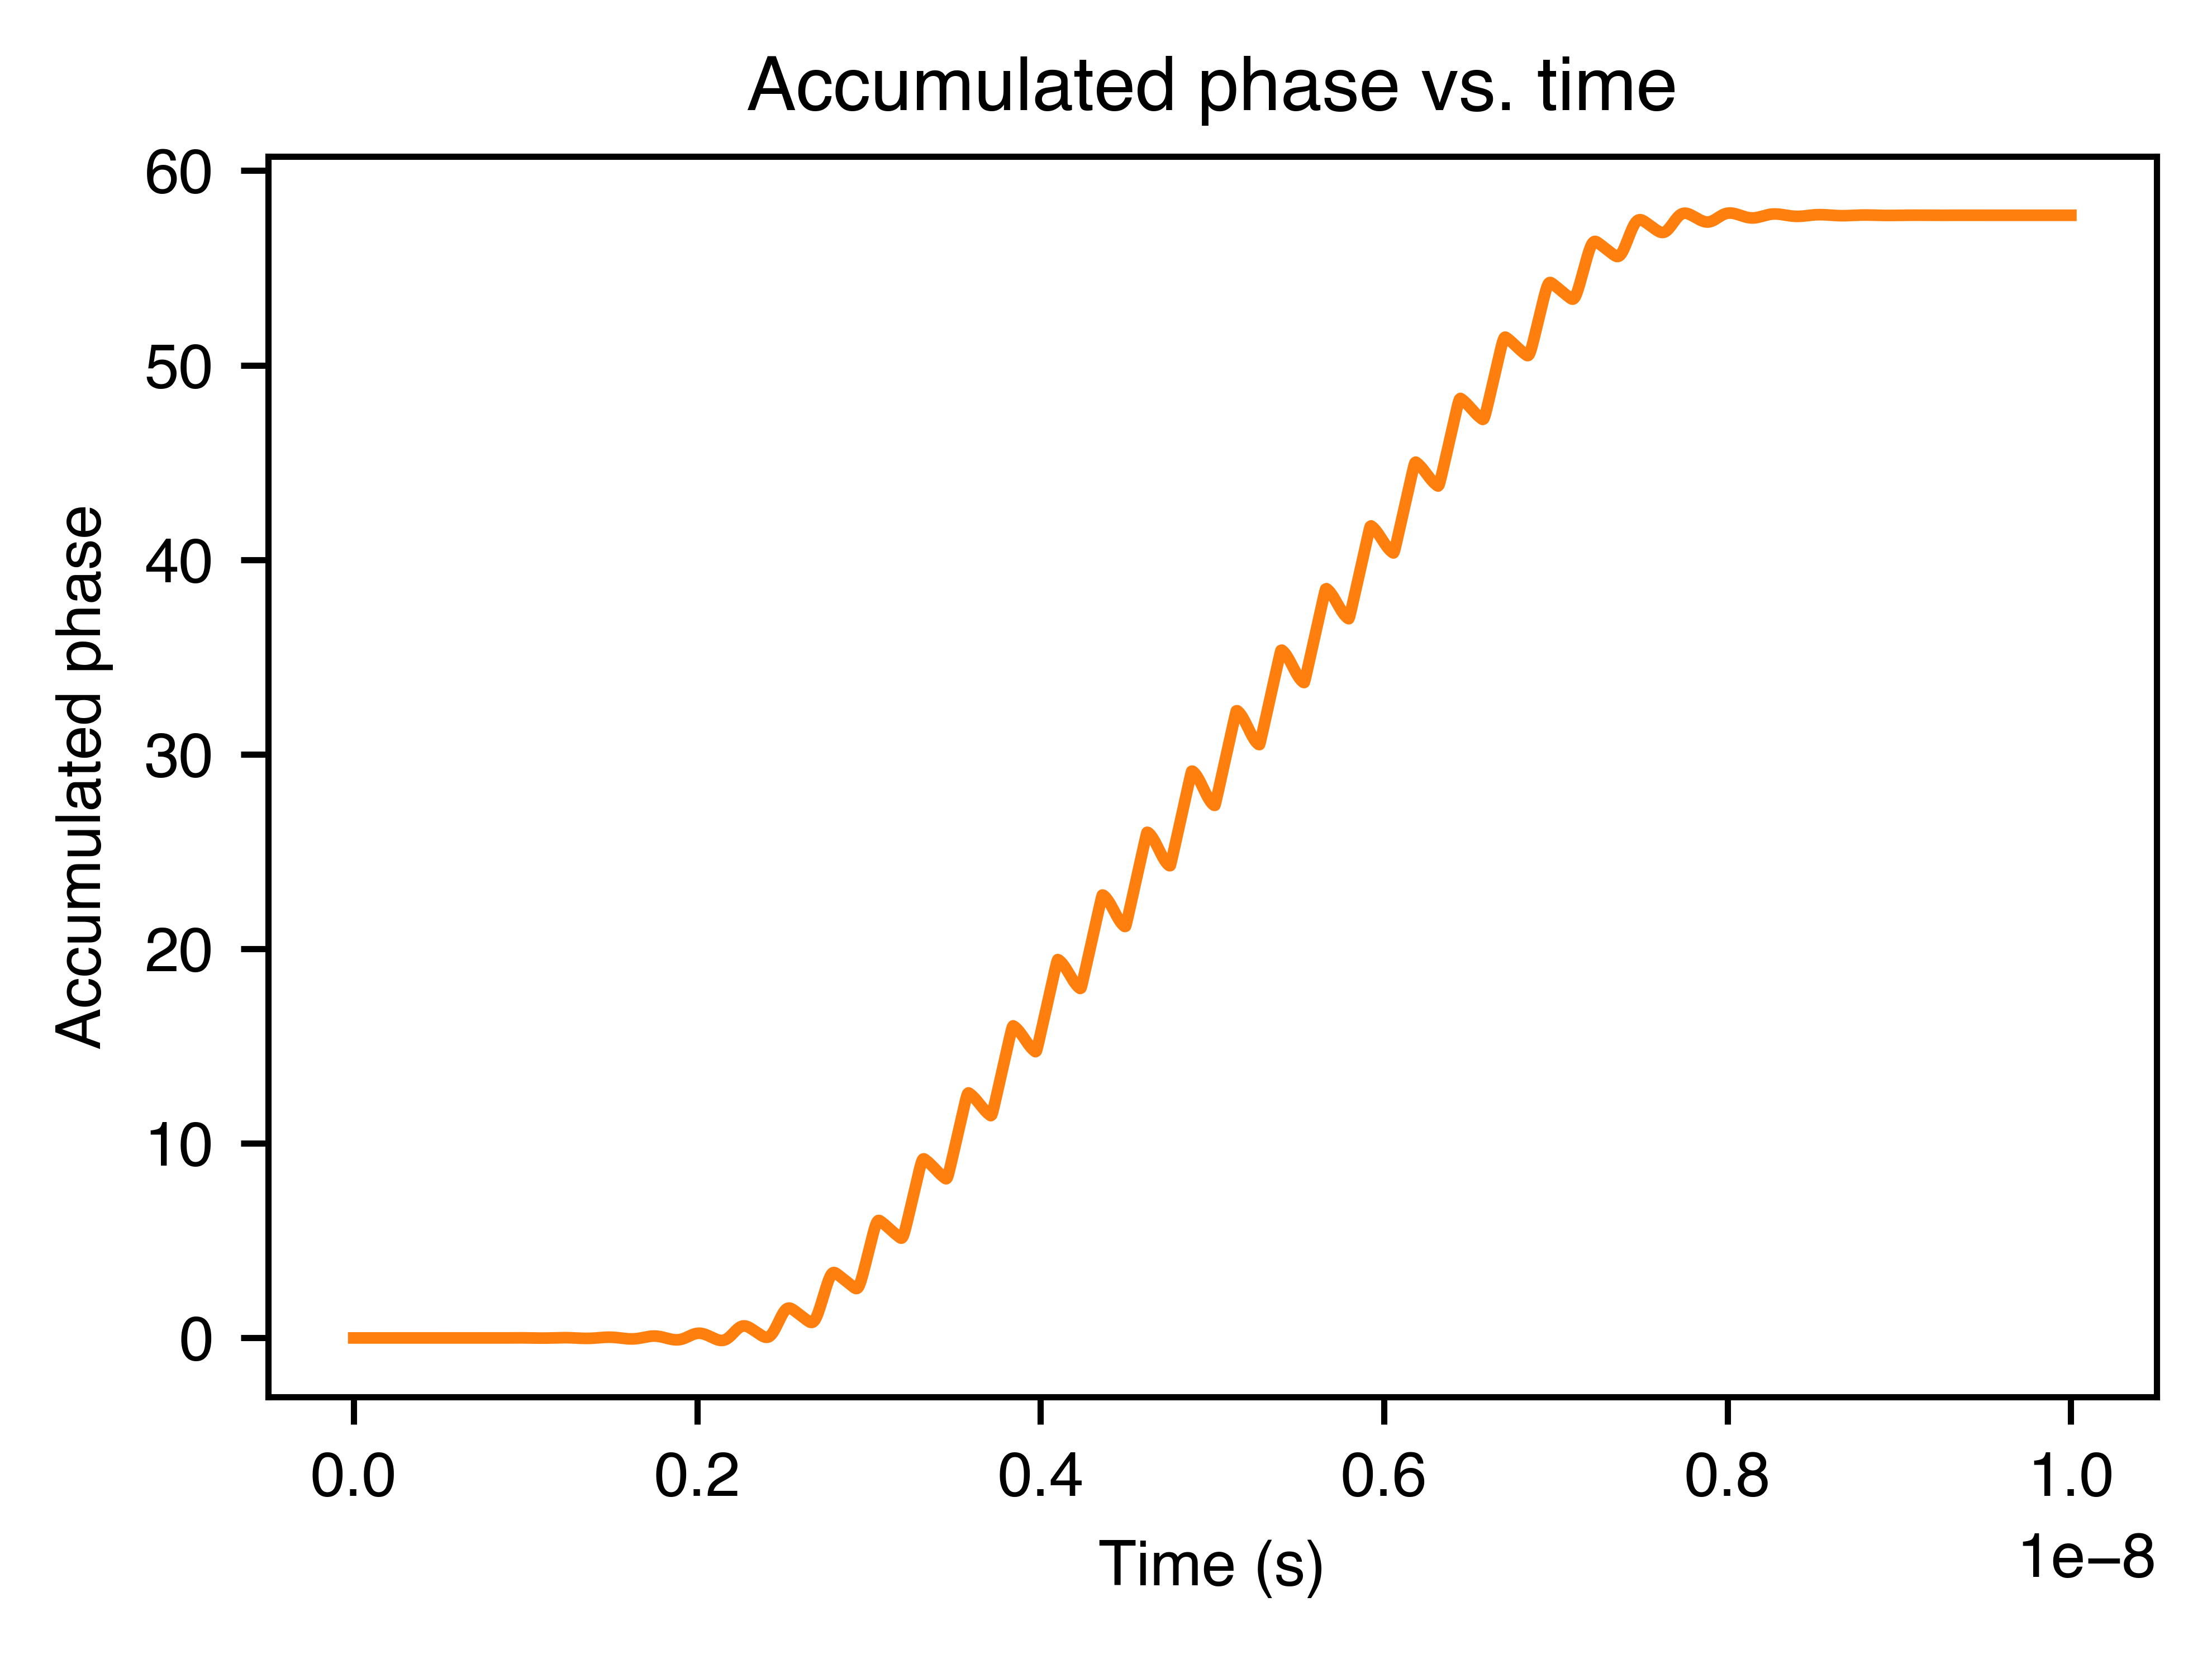

In [86]:
# Not sure I'm computing phase correctly. I'll try a different way.
accPhi01 = np.zeros(nTimes+1)
accPhi01[0] = 0
for i in tqdm(range(nTimes)):
    hTot = h + hDrive(pulseVals[i+1], rabiMatEl)
    eigVals, eigVecs = scipy.linalg.eigh(hTot)
    omega01 = 2*np.pi*(eigVals[1] - eigVals[0]) # Drive frequency
    domega01 = omega01-omegaD
    accPhi01[i+1] = domega01*dt + accPhi01[i]

fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
ax.plot(times, accPhi01, label='$\\phi_{10} (t)$', color='C1')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accumulated phase')
# ax.legend()
ax.set_title('Accumulated phase vs. time')
plt.tight_layout()

# Archive:

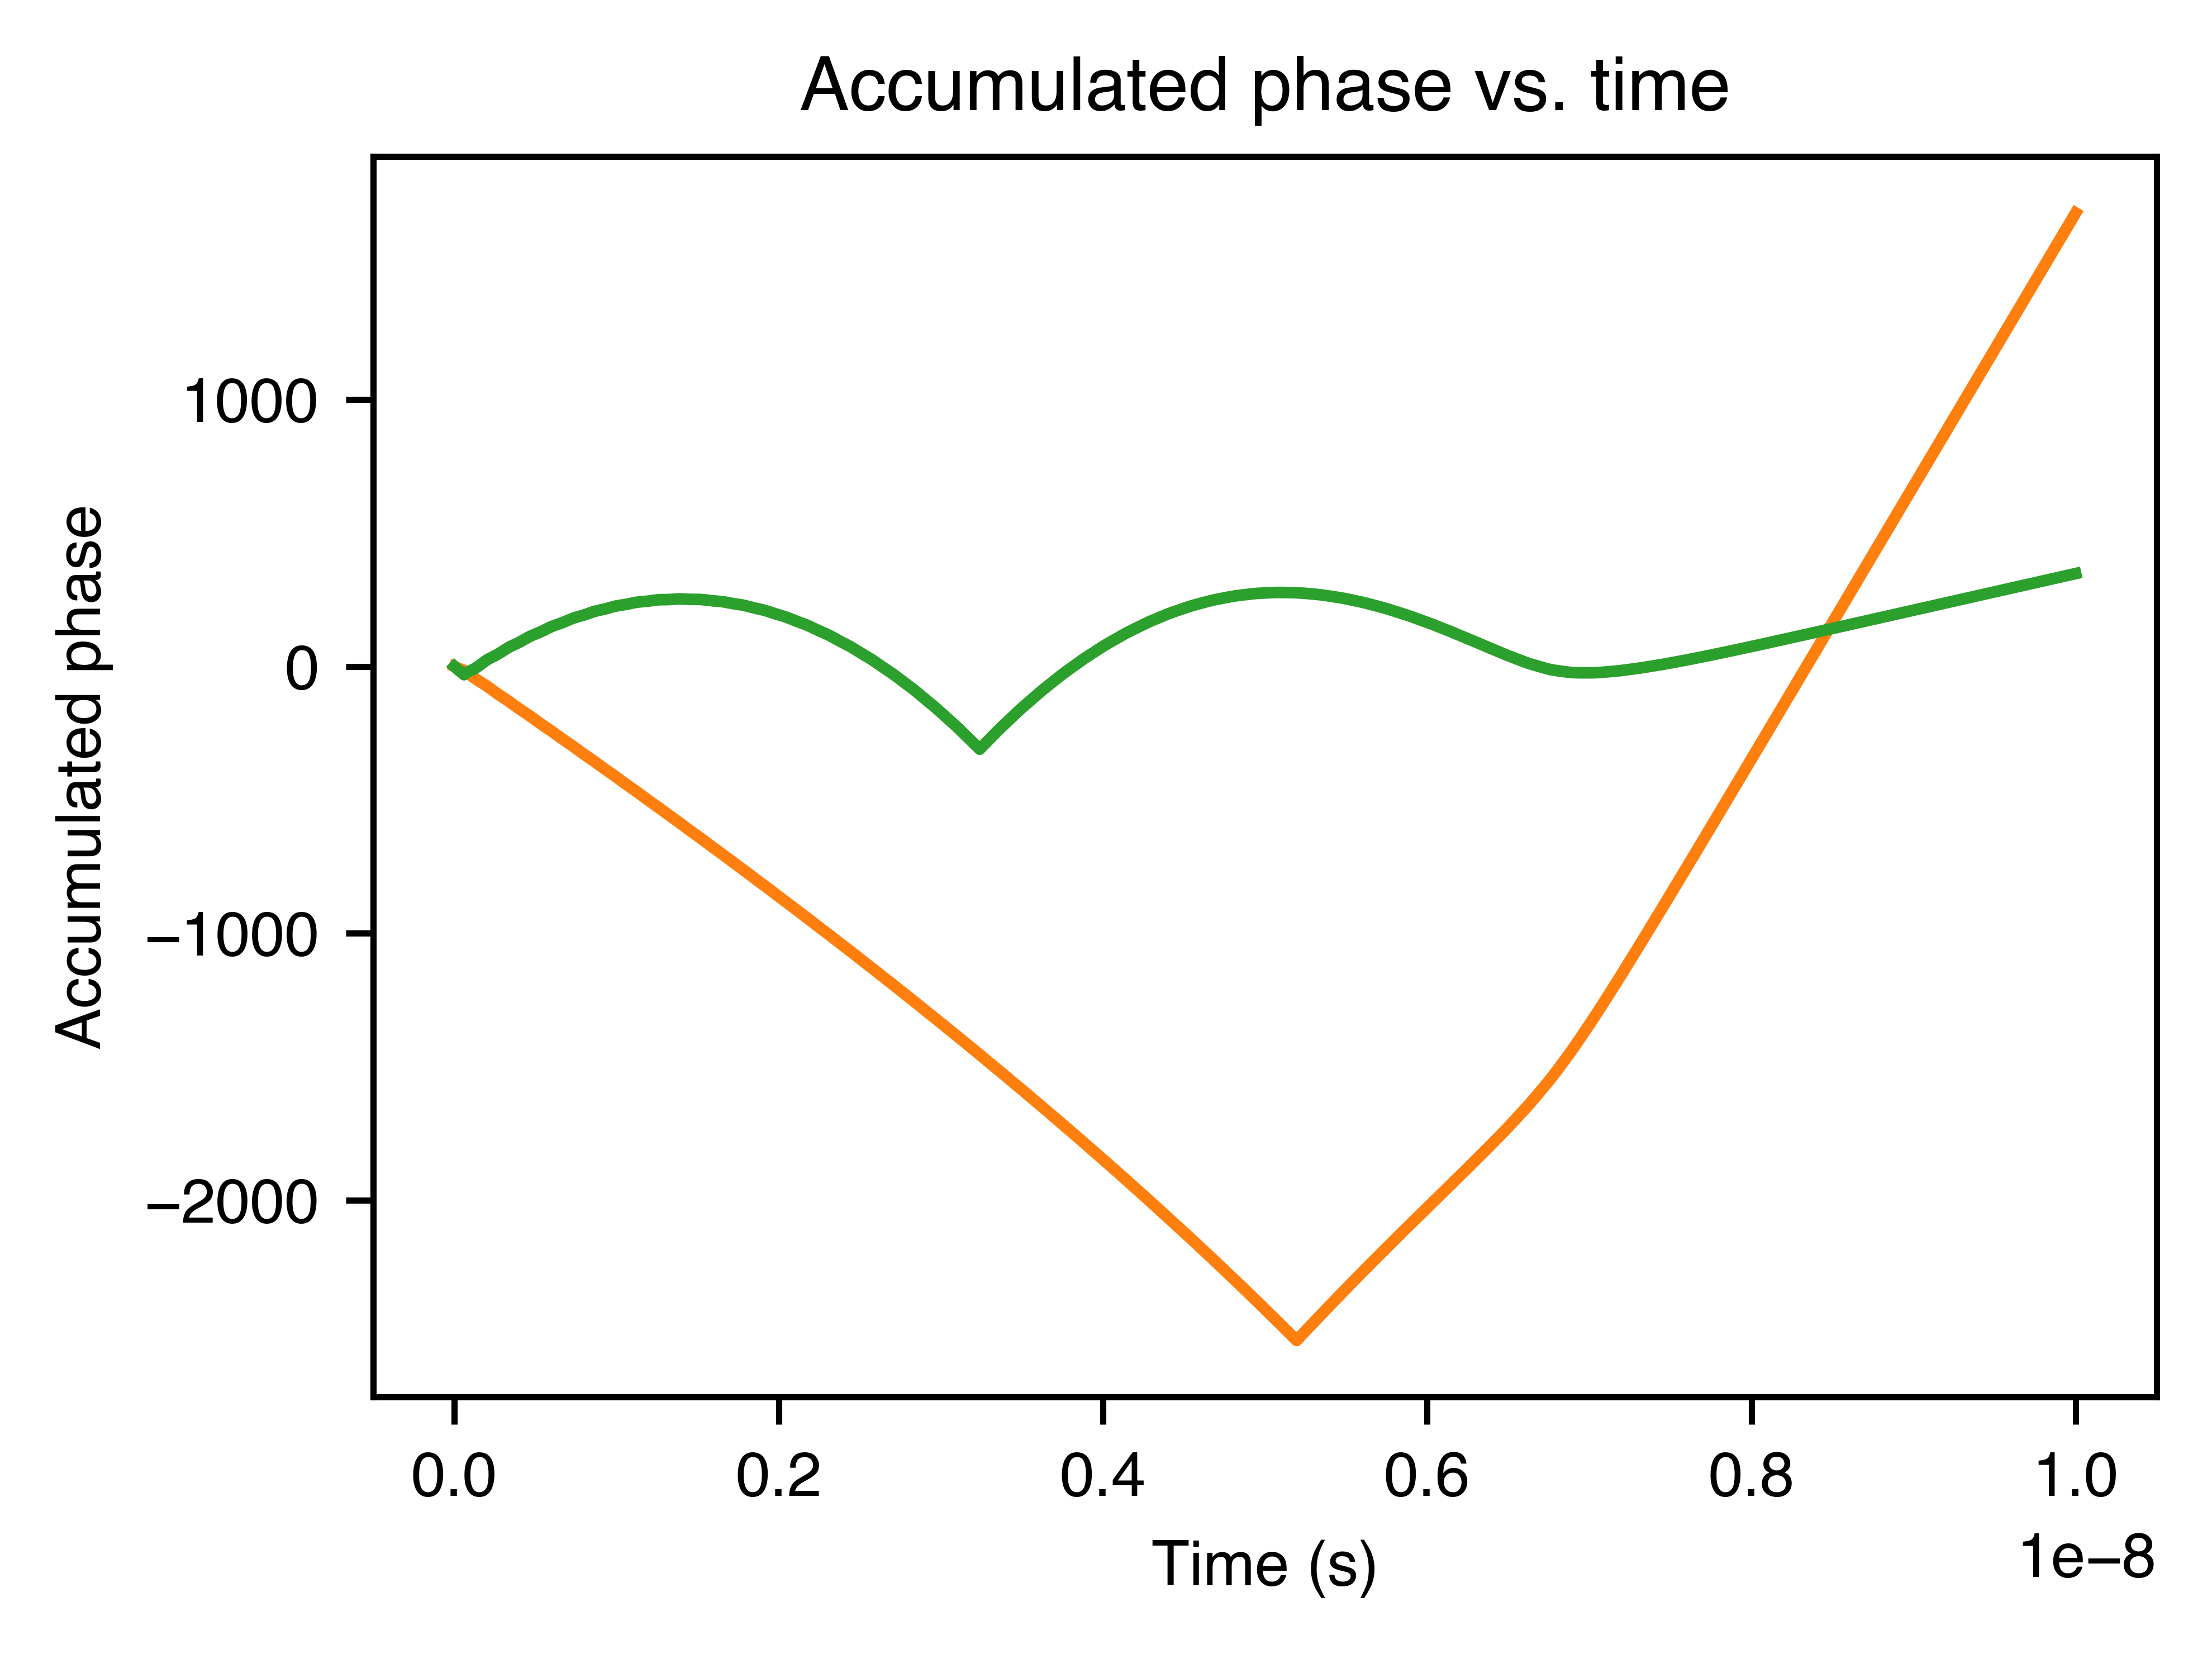

In [25]:
# Plot the results:
fig, ax = plt.subplots(figsize=(4, 3), dpi=1000)
# Get the initial phases of the first three states, which are taken to be the phases of the un-driven Hamiltonian:
phi0Ref = np.angle(populations[0, 0])
phi1Ref = np.angle(populations[1, 0])
phi2Ref = np.angle(populations[2, 0])
# Compute the phases at all points in the evolution:
phi0s = np.angle(populations[0, :].A1)
phi1s = np.angle(populations[1, :].A1)
phi2s = np.angle(populations[2, :].A1)
# Compute the relative phases:
phi10s = phi1s - phi0s
phi10Ref = phi10s[0]
phi20s = phi2s - phi0s
phi20Ref = phi20s[0]
# Compute the phase difference that is accumulated throughout the evolution:
accPhi10 = np.zeros(nTimes+1)
accPhi10[0] = 0
for i, phi10 in enumerate(phi10s[1:]):
    dphi10 = phi10 - phi10Ref
    accPhi10[i+1] = dphi10 + accPhi10[i]
accPhi20 = np.zeros(nTimes+1)
accPhi20[0] = 0
for i, phi20 in enumerate(phi20s[1:]):
    dphi20 = phi20 - phi20Ref
    accPhi20[i+1] = dphi20 + accPhi20[i]

# dphi1 = phi1 - phi0
# dphi2 = phi2 - phi0
# ax.plot(times, dphi1, label='$\\delta \\phi_1$', color='C1')
# ax.plot(times, dphi2, label='$\\delta \\phi_2$', color='C2')
ax.plot(times, accPhi10, label='$\\phi_{10} (t)$', color='C1')
ax.plot(times, accPhi20, label='$\\phi_{20} (t)$', color='C2')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accumulated phase')
# ax.legend()
ax.set_title('Accumulated phase vs. time')
plt.tight_layout()
# phi0 = np.angle(populations[0, :].A1)
# phi1 = np.angle(populations[1, :].A1)
# phi2 = np.angle(populations[2, :].A1)
# dphi1 = phi1 - phi0
# dphi2 = phi2 - phi0
# ax.plot(times, dphi1, label='$\\delta \\phi_1$', color='C1')
# ax.plot(times, dphi2, label='$\\delta \\phi_2$', color='C2')
# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Phase')
# ax.legend()
# ax.set_title('Phase vs. time')
# plt.tight_layout()